# Deep Hedging, the complete build

### The full project in one notebook: every piece of code, and the story around it

This notebook contains the actual code of the whole project, copied from the twenty notebooks we built, in order, with the narrative around it in English. It is meant to be read as one continuous story, from the first simulation to the final quote, with the results and the difficulties explained as they happened. The shared pricers are defined once in a toolbox cell at the top; each chapter then redefines only its own parameters and its chapter-specific code (the simulators that close over model parameters, the CVaR variants, and the training loops). Run the toolbox first, then any chapter.

**The thesis.** Deep hedging treats hedging as a policy the network learns by minimizing a tail risk measure under transaction costs. On easy problems it reproduces the textbook hedge, which is the honest baseline. It earns its keep once the market has frictions, is incomplete, or the payoff is exotic, and the very same machinery then prices the option and quotes a bid-ask spread that measures how hard it is to hedge.

**The map.**

| Notebooks | Chapter | Result |
|---|---|---|
| 01 to 04 | Foundations | simulate, price, delta hedge, add costs, verify all of it |
| 05 to 06 | The deep hedger | matches delta, matches the best no-trade band |
| 07 to 08 | Stochastic volatility | Heston, incompleteness, the floor delta hedging cannot beat |
| 09 to 10 | Deep hedging under Heston | 16 percent better with no cost, 14 percent better with cost |
| 11, 11b | Pricing and tabulation | Heston by Fourier, tabulate and interpolate, the convexity bias |
| 12 | A second instrument | vega hedging, CVaR 2.45 |
| 13 | Reckoning and barrier | the honest decomposition, then the exotic where dynamics win |
| 14, 14b, 14c | Robustness | robustness is a property of the product, not of the method |
| 15, 15b | The hedger as pricer | indifference price, spread, realistic desk calibration |

**A note on running it.** The numpy and scipy cells are self-contained. The PyTorch training cells were validated separately and are included as they were run; on a laptop each takes from under a minute to a few minutes. Run the toolbox cell first. After that, some cells expect the earlier cells of the same chapter to have run, since each chapter is a former standalone notebook.

**Two conventions repeated everywhere.** `theta` in Heston is the long-run variance, so the volatility is its square root. And the CVaR loss is the direct empirical form, the mean of the losses beyond the 95 percent quantile, for a reason we explain the hard way in chapter 8.


## Shared toolbox

The pricers below are used in many chapters. To avoid repeating them, they are defined once here. Run this cell first. Chapter-specific code (simulators that close over model parameters, the CVaR variants, and the training loops) stays inside each chapter.


In [1]:
# ============================================================================
# Shared toolbox : pricers used across many chapters, defined once here.
# (Simulators, CVaR variants and training loops stay local to each chapter,
#  because they close over chapter-specific parameters.)
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import brentq


def bs_price(S, K, tau, r, sigma, kind="call"):
    """Black-Scholes European price."""
    S = np.asarray(S, float)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    call = S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
    return call if kind == "call" else call - S + K * np.exp(-r * tau)


def bs_delta(S, K, tau, r, sigma, kind="call"):
    """Black-Scholes delta = dPrice/dS. For a call, N(d1)."""
    S = np.asarray(S, float)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * tau) / (sigma * np.sqrt(tau))
    return norm.cdf(d1) if kind == "call" else norm.cdf(d1) - 1.0


def heston_cf(phi, S0, v0, r, kappa, theta, xi, rho, T):
    out = []
    for u, b in [(0.5, kappa - rho * xi), (-0.5, kappa)]:
        d = np.sqrt((rho * xi * 1j * phi - b) ** 2 - xi ** 2 * (2 * u * 1j * phi - phi ** 2))
        g = (b - rho * xi * 1j * phi + d) / (b - rho * xi * 1j * phi - d)
        C = r * 1j * phi * T + (kappa * theta / xi ** 2) * (
            (b - rho * xi * 1j * phi + d) * T - 2 * np.log((1 - g * np.exp(d * T)) / (1 - g)))
        D = (b - rho * xi * 1j * phi + d) / xi ** 2 * ((1 - np.exp(d * T)) / (1 - g * np.exp(d * T)))
        out.append(np.exp(C + D * v0 + 1j * phi * np.log(S0)))
    return out


def heston_call(S0, v0, r, kappa, theta, xi, rho, T, K):
    def integ(phi, i):
        f = heston_cf(phi, S0, v0, r, kappa, theta, xi, rho, T)[i]
        return (np.exp(-1j * phi * np.log(K)) * f / (1j * phi)).real
    P1 = 0.5 + quad(integ, 1e-8, 200, args=(0,), limit=200)[0] / np.pi
    P2 = 0.5 + quad(integ, 1e-8, 200, args=(1,), limit=200)[0] / np.pi
    return S0 * P1 - K * np.exp(-r * T) * P2


def bs_uo_call(S, X, H, T, r, sig):
    """Up-and-out call (strike X < barrier H), continuous monitoring."""
    S = np.asarray(S, float)
    srt = sig * np.sqrt(T)
    mu = (r - 0.5 * sig ** 2) / sig ** 2
    x1 = np.log(S / X) / srt + (1 + mu) * srt
    x2 = np.log(S / H) / srt + (1 + mu) * srt
    y1 = np.log(H ** 2 / (S * X)) / srt + (1 + mu) * srt
    y2 = np.log(H / S) / srt + (1 + mu) * srt
    A = S * norm.cdf(x1) - X * np.exp(-r * T) * norm.cdf(x1 - srt)
    B = S * norm.cdf(x2) - X * np.exp(-r * T) * norm.cdf(x2 - srt)
    C = S * (H / S) ** (2 * (mu + 1)) * norm.cdf(-y1) - X * np.exp(-r * T) * (H / S) ** (2 * mu) * norm.cdf(-y1 + srt)
    D = S * (H / S) ** (2 * (mu + 1)) * norm.cdf(-y2) - X * np.exp(-r * T) * (H / S) ** (2 * mu) * norm.cdf(-y2 + srt)
    return np.where(S >= H, 0.0, A - B + C - D)


def bs_uo_delta(S, X, H, T, r, sig, h=0.5):
    return (bs_uo_call(S + h, X, H, T, r, sig) - bs_uo_call(S - h, X, H, T, r, sig)) / (2 * h)


## Chapter 1. Foundations

We started with the simplest complete market and built upward, verifying every block before trusting it.

### 1.1 Simulating the market, and checking it against theory (notebook 01)

Geometric Brownian motion, using the exact log-normal solution rather than an Euler scheme, because we know the closed form so we may as well be exact. The code below simulates the paths and then verifies them against theory: the terminal mean must equal `S0 exp(mu T)`, and the log-return must be Gaussian with mean `(mu - sigma^2/2)T` and variance `sigma^2 T`. A simulator you have not checked against theory is a silent source of wrong conclusions for the rest of the project, so this verification is not optional.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

RNG = np.random.default_rng(0)   # générateur à graine fixe, pour la reproductibilité

In [3]:
def simulate_gbm(S0, mu, sigma, T, n_steps, n_paths, rng=RNG):
    """Simule n_paths trajectoires de brownien géométrique sur [0, T].
    Renvoie S de forme (n_paths, n_steps + 1) : colonnes = dates t_0..t_n."""
    dt = T / n_steps                                   # pas de temps entre deux dates

    # Un incrément brownien standard normal par (trajectoire, pas de temps).
    Z = rng.standard_normal((n_paths, n_steps))

    # Incréments du LOG du prix : d(ln S) = (mu - sigma^2/2) dt + sigma dW,
    # avec dW = sqrt(dt) Z. Le -sigma^2/2 est la correction d'Ito.
    log_increments = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

    # log-prix en t_k = ln S0 + somme des incréments jusqu'à k. On cumule sur le
    # temps (axis=1) et on colle une colonne de zéros pour t_0.
    zeros = np.zeros((n_paths, 1))
    log_paths = np.concatenate([zeros, np.cumsum(log_increments, axis=1)], axis=1)

    # retour du log au prix : S = S0 exp(log_paths)
    S = S0 * np.exp(log_paths)
    return S

In [4]:
# Paramètres du marché (un an, 252 jours de bourse, vol 20 %).
S0, mu, sigma, T = 100.0, 0.05, 0.20, 1.0
n_steps, n_paths = 252, 200_000

S = simulate_gbm(S0, mu, sigma, T, n_steps, n_paths)
ST = S[:, -1]                        # prix final de chaque trajectoire

# Vérif 1 : E[S_T] = S0 exp(mu T)  (le fait qu'on a démontré via la martingale)
print(f"E[S_T] empirique = {ST.mean():.4f}   |   théorie S0*exp(mu*T) = {S0*np.exp(mu*T):.4f}")

# Vérif 2 : ln(S_T/S0) ~ Normal( (mu - sigma^2/2) T , sigma^2 T )
logret = np.log(ST / S0)
print(f"moyenne log-ret  = {logret.mean():.4f}   |   théorie (mu-sigma^2/2)*T = {(mu-0.5*sigma**2)*T:.4f}")
print(f"variance log-ret = {logret.var():.4f}   |   théorie sigma^2*T        = {sigma**2*T:.4f}")

E[S_T] empirique = 105.1493   |   théorie S0*exp(mu*T) = 105.1271
moyenne log-ret  = 0.0303   |   théorie (mu-sigma^2/2)*T = 0.0300
variance log-ret = 0.0399   |   théorie sigma^2*T        = 0.0400


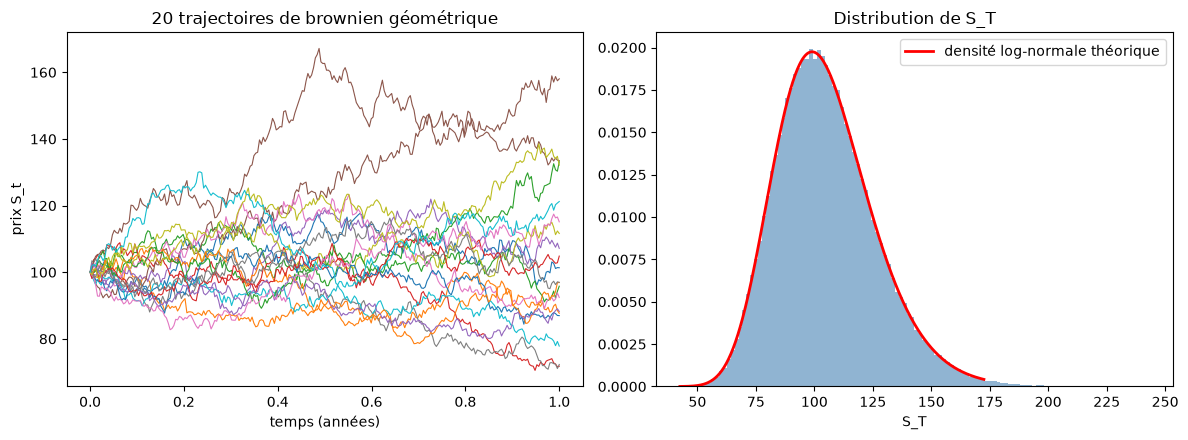

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# 20 trajectoires pour l'oeil
for i in range(20):
    ax1.plot(np.linspace(0, T, n_steps + 1), S[i], lw=0.8)
ax1.set_title("20 trajectoires de brownien géométrique")
ax1.set_xlabel("temps (années)"); ax1.set_ylabel("prix S_t")

# histogramme de S_T + densité log-normale théorique
ax2.hist(ST, bins=120, density=True, alpha=0.6, color="steelblue")
x = np.linspace(ST.min(), np.percentile(ST, 99.5), 400)
m = np.log(S0) + (mu - 0.5 * sigma**2) * T          # moyenne du log
s = sigma * np.sqrt(T)                               # écart-type du log
pdf = np.exp(-(np.log(x) - m)**2 / (2 * s**2)) / (x * s * np.sqrt(2 * np.pi))
ax2.plot(x, pdf, "r", lw=2, label="densité log-normale théorique")
ax2.set_title("Distribution de S_T"); ax2.set_xlabel("S_T"); ax2.legend()

plt.tight_layout()
plt.show()

### 1.2 Black-Scholes price and greeks (notebook 02)

The closed-form European call price and its delta, verified two ways: by put-call parity, and against a Monte Carlo price from the simulator we just trusted. This gives us the analytic delta that the classical hedger uses and that the network will be measured against.

In [6]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [7]:
K, tau, r, sigma = 100.0, 1.0, 0.02, 0.20
for S in [80, 100, 120]:
    C = bs_price(S, K, tau, r, sigma, "call")
    P = bs_price(S, K, tau, r, sigma, "put")
    print(f"S={S}: C-P = {C-P:.6f}   S - K e^-r tau = {S - K*np.exp(-r*tau):.6f}")

S=80: C-P = -18.019867   S - K e^-r tau = -18.019867
S=100: C-P = 1.980133   S - K e^-r tau = 1.980133
S=120: C-P = 21.980133   S - K e^-r tau = 21.980133


In [8]:
h = 1e-4
for S in [80, 100, 120]:
    fd = (bs_price(S+h, K, tau, r, sigma) - bs_price(S-h, K, tau, r, sigma)) / (2*h)
    an = bs_delta(S, K, tau, r, sigma)
    print(f"S={S}: delta analytique = {an:.6f}   diff finie = {fd:.6f}   écart = {abs(an-fd):.2e}")

S=80: delta analytique = 0.179907   diff finie = 0.179907   écart = 1.21e-11
S=100: delta analytique = 0.579260   diff finie = 0.579260   écart = 1.35e-11
S=120: delta analytique = 0.866847   diff finie = 0.866847   écart = 3.50e-11


In [9]:
for S, lab in [(200,"très ITM"), (100,"ATM"), (40,"très OTM")]:
    print(f"{lab:9s} (S={S}): delta = {bs_delta(S,K,tau,r,sigma):.4f}")

très ITM  (S=200): delta = 0.9999
ATM       (S=100): delta = 0.5793
très OTM  (S=40): delta = 0.0000


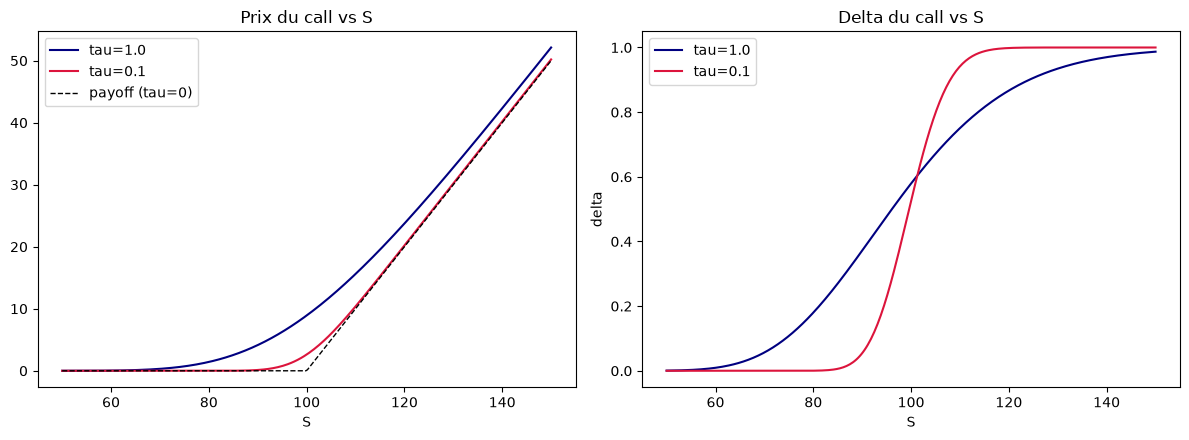

In [10]:
Sgrid = np.linspace(50, 150, 300)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
for tt, c in [(1.0, "navy"), (0.1, "crimson")]:
    ax1.plot(Sgrid, bs_price(Sgrid, K, tt, r, sigma), c, label=f"tau={tt}")
    ax2.plot(Sgrid, bs_delta(Sgrid, K, tt, r, sigma), c, label=f"tau={tt}")
ax1.plot(Sgrid, np.maximum(Sgrid-K, 0), "k--", lw=1, label="payoff (tau=0)")
ax1.set_title("Prix du call vs S"); ax1.set_xlabel("S"); ax1.legend()
ax2.set_title("Delta du call vs S"); ax2.set_xlabel("S"); ax2.set_ylabel("delta"); ax2.legend()
plt.tight_layout(); plt.show()

### 1.3 Delta hedging (notebook 03)

Replicating a short call by holding the delta and rebalancing on a grid. The result to see is that the hedging error shrinks as we rebalance more often, converging toward perfect replication in the frictionless limit. This is the classical benchmark that everything later has to beat.

In [11]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
RNG = np.random.default_rng(0)

In [12]:
def simulate_gbm(S0, mu, sigma, T, n_steps, n_paths, rng=RNG):
    dt = T/n_steps
    Z = rng.standard_normal((n_paths, n_steps))
    inc = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
    logp = np.concatenate([np.zeros((n_paths,1)), np.cumsum(inc, axis=1)], axis=1)
    return S0*np.exp(logp)


In [13]:
def delta_hedge_pnl(S, K, T, r, sigma, cost=0.0):
    """P&L final d'un vendeur de call qui se delta-couvre. S : (n_paths, n_steps+1)."""
    n_paths, n1 = S.shape
    n_steps = n1 - 1
    dt = T / n_steps
    times = np.linspace(0, T, n1)

    cash = bs_price(S[:, 0], K, T, r, sigma).copy()   # prime encaissée en vendant le call
    shares = np.zeros(n_paths)                         # aucune action au départ

    for k in range(n_steps):
        tau = T - times[k]                             # temps restant à cette date
        delta_k = bs_delta(S[:, k], K, tau, r, sigma)  # delta cible, par trajectoire
        trade = delta_k - shares                       # actions à acheter (ou vendre)
        cash -= trade * S[:, k]                        # on paie ces actions
        cash -= cost * np.abs(trade) * S[:, k]         # coût de transaction (0 ici)
        shares = delta_k                               # nouvelle position
        cash *= np.exp(r * dt)                          # le cash capitalise jusqu'à la date suivante

    payoff = np.maximum(S[:, -1] - K, 0.0)             # ce qu'on doit payer en T
    return cash + shares * S[:, -1] - payoff           # P&L final

In [14]:
S0, K, mu, r, sigma, T = 100., 100., 0.10, 0.02, 0.20, 1.0
n_paths = 100_000
ns = [5, 21, 63, 252, 1000]

print(f"{'n_steps':>8} | {'moyenne P&L':>12} | {'std P&L':>10} | {'std*sqrt(n)':>12}")
stds = []
for n in ns:
    S = simulate_gbm(S0, mu, sigma, T, n, n_paths)
    pnl = delta_hedge_pnl(S, K, T, r, sigma, cost=0.0)
    stds.append(pnl.std())
    print(f"{n:>8} | {pnl.mean():>12.4f} | {pnl.std():>10.4f} | {pnl.std()*np.sqrt(n):>12.3f}")

 n_steps |  moyenne P&L |    std P&L |  std*sqrt(n)
       5 |      -0.1352 |     2.9546 |        6.607
      21 |      -0.0222 |     1.4608 |        6.694
      63 |      -0.0057 |     0.8544 |        6.782
     252 |      -0.0037 |     0.4321 |        6.859
    1000 |      -0.0017 |     0.2190 |        6.927


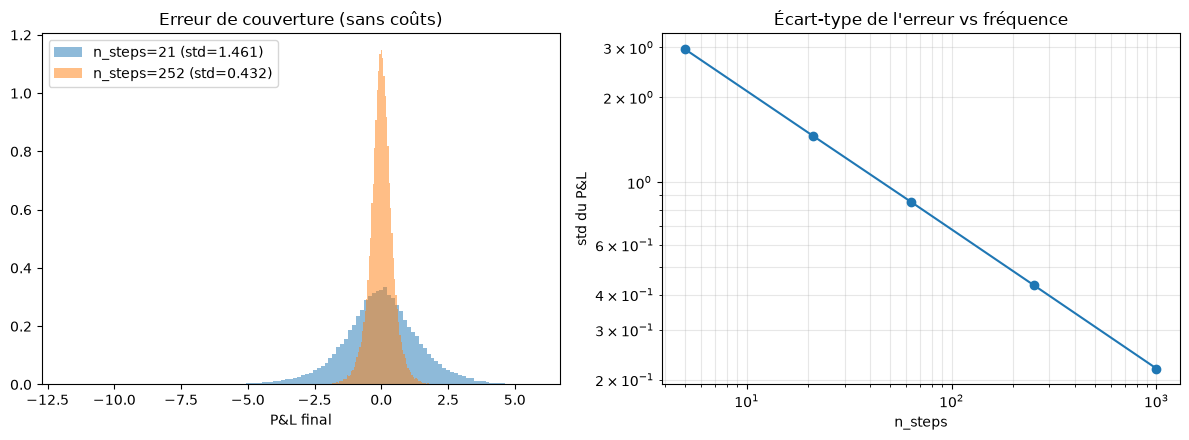

In [15]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
for n, c in [(21, "crimson"), (252, "navy")]:
    S = simulate_gbm(S0, mu, sigma, T, n, n_paths)
    pnl = delta_hedge_pnl(S, K, T, r, sigma)
    a1.hist(pnl, bins=120, density=True, alpha=0.5, label=f"n_steps={n} (std={pnl.std():.3f})")
a1.set_title("Erreur de couverture (sans coûts)"); a1.set_xlabel("P&L final"); a1.legend()

a2.loglog(ns, stds, "o-")
a2.set_title("Écart-type de l'erreur vs fréquence")
a2.set_xlabel("n_steps"); a2.set_ylabel("std du P&L"); a2.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

### 1.4 Transaction costs, where the problem stops being trivial (notebook 04)

With proportional costs, rebalancing every step bleeds money and never fully removes gamma risk, so there is a real tradeoff between tracking error and cost. The classical answer is a no-trade band: only trade when the position drifts far enough from the target. We tune the band width and record the best classical result. The real question of the whole project is now set: can a network find a better rule than a hand-tuned band?

In [16]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
RNG = np.random.default_rng(0)

In [17]:
def simulate_gbm(S0, mu, sigma, T, n_steps, n_paths, rng=RNG):
    dt = T/n_steps
    Z = rng.standard_normal((n_paths, n_steps))
    inc = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
    return S0*np.exp(np.concatenate([np.zeros((n_paths,1)), np.cumsum(inc,axis=1)], axis=1))

def delta_hedge_pnl(S, K, T, r, sigma, cost=0.0):
    m, n1 = S.shape; n = n1-1; dt = T/n; times = np.linspace(0,T,n1)
    cash = bs_price(S[:,0],K,T,r,sigma).copy(); sh = np.zeros(m)
    for k in range(n):
        tau = T-times[k]; dk = bs_delta(S[:,k],K,tau,r,sigma); tr = dk-sh
        cash -= tr*S[:,k]; cash -= cost*np.abs(tr)*S[:,k]; sh = dk; cash *= np.exp(r*dt)
    return cash + sh*S[:,-1] - np.maximum(S[:,-1]-K, 0.0)

In [18]:
def cvar(pnl, alpha=0.95):
    """CVaR de la perte L = -pnl : moyenne des pires (1-alpha) scénarios."""
    loss = -pnl
    var = np.quantile(loss, alpha)
    return loss[loss >= var].mean()

In [19]:
S0, K, mu, r, sigma, T = 100., 100., 0.10, 0.02, 0.20, 1.0
m = 100_000
ns = [5, 10, 21, 42, 63, 126, 252]

for cost in [0.0, 0.005, 0.02]:
    print(f"=== coût = {cost:.1%} ===")
    print(f"{'n_steps':>8} | {'moy P&L':>9} | {'std':>7} | {'CVaR95':>8}")
    for n in ns:
        S = simulate_gbm(S0, mu, sigma, T, n, m)
        pnl = delta_hedge_pnl(S, K, T, r, sigma, cost)
        print(f"{n:>8} | {pnl.mean():>9.3f} | {pnl.std():>7.3f} | {cvar(pnl):>8.3f}")
    print()

=== coût = 0.0% ===
 n_steps |   moy P&L |     std |   CVaR95
       5 |    -0.135 |   2.955 |    7.292
      10 |    -0.059 |   2.105 |    5.069
      21 |    -0.024 |   1.459 |    3.438
      42 |    -0.013 |   1.041 |    2.435
      63 |    -0.008 |   0.853 |    1.977
     126 |    -0.004 |   0.604 |    1.389
     252 |    -0.003 |   0.434 |    0.994

=== coût = 0.5% ===
 n_steps |   moy P&L |     std |   CVaR95
       5 |    -0.726 |   3.002 |    7.994
      10 |    -0.825 |   2.150 |    6.030
      21 |    -1.015 |   1.534 |    4.798
      42 |    -1.303 |   1.155 |    4.232
      63 |    -1.536 |   1.014 |    4.147
     126 |    -2.038 |   0.933 |    4.386
     252 |    -2.755 |   1.060 |    5.168

=== coût = 2.0% ===
 n_steps |   moy P&L |     std |   CVaR95
       5 |    -2.516 |   3.170 |   10.266
      10 |    -3.095 |   2.368 |    9.034
      21 |    -3.994 |   1.927 |    8.998
      42 |    -5.176 |   1.921 |    9.956
      63 |    -6.093 |   2.124 |   11.077
     126 |    

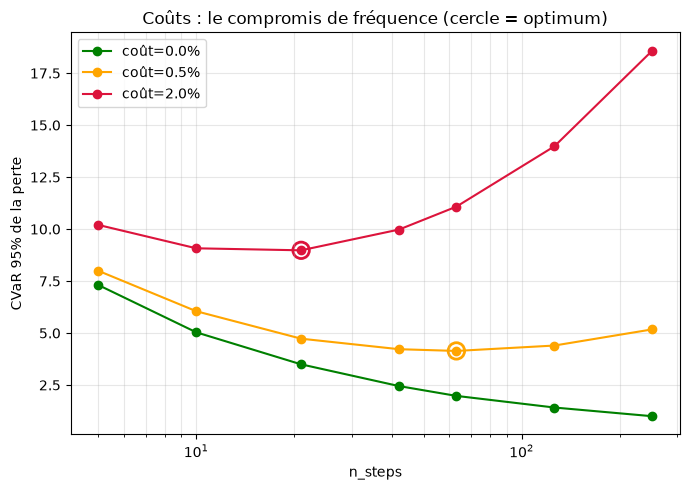

In [20]:
ns = [5, 10, 21, 42, 63, 126, 252]
fig, ax = plt.subplots(figsize=(7, 5))
for cost, c in [(0.0, "green"), (0.005, "orange"), (0.02, "crimson")]:
    cs = [cvar(delta_hedge_pnl(simulate_gbm(S0, mu, sigma, T, n, m), K, T, r, sigma, cost)) for n in ns]
    ax.plot(ns, cs, "o-", color=c, label=f"coût={cost:.1%}")
    if cost > 0:
        i = int(np.argmin(cs))
        ax.scatter([ns[i]], [cs[i]], s=140, facecolors="none", edgecolors=c, linewidths=2)
ax.set_xscale("log"); ax.set_xlabel("n_steps"); ax.set_ylabel("CVaR 95% de la perte")
ax.set_title("Coûts : le compromis de fréquence (cercle = optimum)")
ax.legend(); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

## Chapter 2. The deep hedger

### 2.1 The CVaR objective in PyTorch (notebook 05)

We frame hedging as minimizing the Conditional Value at Risk of the hedged loss, the average loss in the worst 5 percent of paths. The network is a small MLP that reads the state and outputs a position, and the entire simulate-and-hedge loop is differentiable, so the gradient of the tail risk flows back through every trade. This cell introduces the CVaR loss and the training loop that the rest of the project reuses.

A note we only fully understood much later, in the barrier chapter: the Rockafellar-Uryasev form of CVaR uses an auxiliary variable that is supposed to converge to the Value at Risk. It works here, but it hides a trap that bit us badly on the barrier. We flag it now and return to it.

In [21]:
import torch
print("torch", torch.__version__)

torch 2.13.0


In [22]:
x = torch.tensor(2.0, requires_grad=True)
y = x**3
y.backward()                 # calcule dy/dx et le stocke dans x.grad
print("x.grad =", x.grad.item(), " (attendu 12)")

x.grad = 12.0  (attendu 12)


In [23]:
def cvar_ru(loss, w, alpha=0.95):
    """Forme RU de la CVaR : convexe en w, différentiable."""
    return w + torch.mean(torch.relu(loss - w)) / (1.0 - alpha)

torch.manual_seed(0)
L = torch.normal(0.0, 1.0, size=(200_000,))      # échantillon de pertes N(0,1)

w = torch.zeros(1, requires_grad=True)           # variable auxiliaire à optimiser
opt = torch.optim.Adam([w], lr=0.05)
for _ in range(2000):
    opt.zero_grad()                              # remet les gradients à zéro
    obj = cvar_ru(L, w)                           # objectif RU
    obj.backward()                                # gradients
    opt.step()                                    # un pas d'optimisation

print(f"w*   = {w.item():.4f}   (VaR empirique {torch.quantile(L,0.95).item():.4f})")
print(f"CVaR = {cvar_ru(L, w).item():.4f}   (théorie ~2.063)")

w*   = 1.6437   (VaR empirique 1.6437)
CVaR = 2.0585   (théorie ~2.063)


In [24]:
beta, sigX, sigE, alpha = 0.8, 1.0, 0.3, 0.95
torch.manual_seed(0)
X   = torch.normal(0.0, sigX, size=(200_000,))
eps = torch.normal(0.0, sigE, size=(200_000,))

h = torch.zeros(1, requires_grad=True)           # le "couvreur" : ici un simple scalaire
w = torch.zeros(1, requires_grad=True)           # auxiliaire CVaR
opt = torch.optim.Adam([h, w], lr=0.01)
for _ in range(3000):
    opt.zero_grad()
    Lh = (beta - h) * X + eps                     # perte couverte
    obj = cvar_ru(Lh, w, alpha)
    obj.backward()
    opt.step()

Lh = (beta - h) * X + eps
print(f"h*   = {h.item():.4f}   (optimum beta = {beta})")
print(f"CVaR = {cvar_ru(Lh, w, alpha).item():.4f}   (plancher {sigE*0.10313/(1-alpha):.4f})")

h*   = 0.7958   (optimum beta = 0.8)
CVaR = 0.6181   (plancher 0.6188)


### 2.2 The first deep hedger, and its two sanity wins (notebook 06)

Two results that had to hold before trusting the method on anything hard. On GBM with no cost, the learned policy reproduces the Black-Scholes delta, because there is nothing to gain and the network agrees. On GBM with cost, it matches the best hand-tuned no-trade band. A method that could not match the classical optimum where that optimum is known would not deserve trust on harder problems.

In [25]:
import torch
import numpy as np
from scipy.stats import norm
torch.manual_seed(0)
print("torch", torch.__version__)

torch 2.13.0


In [26]:
S0, K, mu, r, sigma, T = 100., 100., 0.10, 0.02, 0.20, 1.0
n, cost, alpha = 63, 0.01, 0.95
dt = T / n
times = torch.linspace(0, T, n + 1)

def simulate_paths(m):
    """m trajectoires GBM, tenseur (m, n+1). Nouvelles à chaque appel."""
    Z = torch.randn(m, n)
    inc = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
    logp = torch.cat([torch.zeros(m, 1), torch.cumsum(inc, dim=1)], dim=1)
    return S0 * torch.exp(logp)

# prime encaissée = prix Black-Scholes du call (constante), calculée en numpy
d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T)); d2 = d1 - sigma*np.sqrt(T)
premium = float(S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2))

def cvar_ru(loss, w, alpha=0.95):
    return w + torch.mean(torch.relu(loss - w)) / (1.0 - alpha)

In [27]:
class HedgeNet(torch.nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(3, hidden), torch.nn.ReLU(),
            torch.nn.Linear(hidden, hidden), torch.nn.ReLU(),
            torch.nn.Linear(hidden, 1),
        )
    def forward(self, x):        # x : (m, 3)  ->  (m,)
        return self.net(x).squeeze(-1)

In [28]:
def hedging_loss(net, w, m):
    S = simulate_paths(m)
    cash = torch.full((m,), premium)             # prime encaissée
    delta_prev = torch.zeros(m)                   # aucune position au départ
    for k in range(n):
        tau = float(T - times[k].item())
        feat = torch.stack([torch.log(S[:, k]/K),
                            torch.full((m,), tau),
                            delta_prev], dim=1)    # (m, 3)
        delta_k = net(feat)                        # position choisie par le réseau
        trade = delta_k - delta_prev
        cash = cash - trade*S[:, k] - cost*torch.abs(trade)*S[:, k]
        cash = cash * np.exp(r*dt)                 # capitalisation
        delta_prev = delta_k
    payoff = torch.clamp(S[:, -1] - K, min=0.0)
    pnl = cash + delta_prev*S[:, -1] - payoff
    return cvar_ru(-pnl, w, alpha)                 # CVaR de la perte

In [29]:
net = HedgeNet()
w = torch.zeros(1, requires_grad=True)
opt = torch.optim.Adam(list(net.parameters()) + [w], lr=1e-3)

n_iter, batch = 2000, 2048
for it in range(n_iter):
    opt.zero_grad()
    loss = hedging_loss(net, w, batch)
    loss.backward()
    opt.step()
    if it % 200 == 0:
        print(f"iter {it:4d}   CVaR (train) = {loss.item():.3f}")

iter    0   CVaR (train) = 186.069
iter  200   CVaR (train) = 27.805
iter  400   CVaR (train) = 20.247
iter  600   CVaR (train) = 15.944
iter  800   CVaR (train) = 15.437
iter 1000   CVaR (train) = 15.170
iter 1200   CVaR (train) = 12.967
iter 1400   CVaR (train) = 13.018
iter 1600   CVaR (train) = 10.205
iter 1800   CVaR (train) = 10.170


In [30]:
with torch.no_grad():
    # grande évaluation hors échantillon
    m = 100_000
    S = simulate_paths(m)
    cash = torch.full((m,), premium); delta_prev = torch.zeros(m)
    for k in range(n):
        tau = float(T - times[k].item())
        feat = torch.stack([torch.log(S[:, k]/K), torch.full((m,), tau), delta_prev], dim=1)
        delta_k = net(feat); trade = delta_k - delta_prev
        cash = cash - trade*S[:, k] - cost*torch.abs(trade)*S[:, k]
        cash = cash * np.exp(r*dt); delta_prev = delta_k
    pnl = cash + delta_prev*S[:, -1] - torch.clamp(S[:, -1]-K, min=0.0)
    loss = -pnl
    var = torch.quantile(loss, alpha)
    cvar = loss[loss >= var].mean()
    print(f"CVaR réseau (hors échantillon) = {cvar.item():.3f}")
    print(f"cibles : delta pur 6.40 | meilleure bande fixe 5.70")

CVaR réseau (hors échantillon) = 5.669
cibles : delta pur 6.40 | meilleure bande fixe 5.70


### 2.3 The classical benchmarks (notebook 06 benchmarks)

The reference hedges we measure against: pure delta, and the delta hedge with a tuned no-trade band. These numbers are the bar the network has to clear in every later setting.

In [31]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)

In [32]:
def simulate_gbm(S0, mu, sigma, T, n, m):
    dt = T/n
    Z = rng.standard_normal((m, n))
    inc = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
    return S0*np.exp(np.concatenate([np.zeros((m,1)), np.cumsum(inc, axis=1)], axis=1))

def band_hedge_pnl(S, K, T, r, s, cost, band):
    """P&L d'un vendeur de call qui rééquilibre vers le delta SEULEMENT si
    |delta_cible - position| > band. band=0 -> delta-hedging pur."""
    m, n1 = S.shape; n = n1-1; dt = T/n; times = np.linspace(0, T, n1)
    cash = bs_price(S[:,0], K, T, r, s).copy(); sh = np.zeros(m)
    for k in range(n):
        tau = T - times[k]
        target = bs_delta(S[:,k], K, tau, r, s)
        trade = np.where(np.abs(target - sh) > band, target - sh, 0.0)   # bande
        cash -= trade*S[:,k]; cash -= cost*np.abs(trade)*S[:,k]
        sh = sh + trade; cash *= np.exp(r*dt)
    return cash + sh*S[:,-1] - np.maximum(S[:,-1]-K, 0.0)

def cvar(pnl, alpha=0.95):
    loss = -pnl
    return loss[loss >= np.quantile(loss, alpha)].mean()

In [33]:
S0, K, mu, r, s, T = 100., 100., 0.10, 0.02, 0.20, 1.0
cost, n, m = 0.01, 63, 120_000
S = simulate_gbm(S0, mu, s, T, n, m)

bands = np.linspace(0, 0.30, 16)
cs = np.array([cvar(band_hedge_pnl(S, K, T, r, s, cost, b)) for b in bands])
i = int(np.argmin(cs))

print(f"CIBLE 1 — delta pur (band=0) : CVaR = {cs[0]:.3f}")
print(f"CIBLE 2 — meilleure bande = {bands[i]:.3f} : CVaR = {cs[i]:.3f}")

CIBLE 1 — delta pur (band=0) : CVaR = 6.399
CIBLE 2 — meilleure bande = 0.080 : CVaR = 5.696


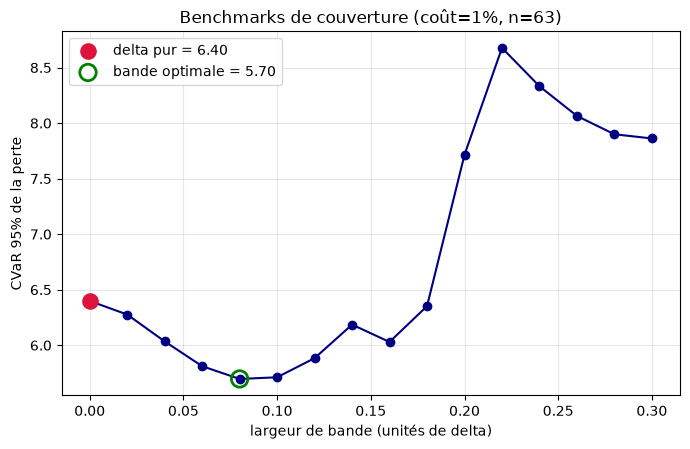

In [34]:
plt.figure(figsize=(7, 4.6))
plt.plot(bands, cs, "o-", color="navy")
plt.scatter([bands[0]], [cs[0]], s=120, color="crimson", zorder=5, label=f"delta pur = {cs[0]:.2f}")
plt.scatter([bands[i]], [cs[i]], s=140, facecolors="none", edgecolors="green",
            linewidths=2, zorder=5, label=f"bande optimale = {cs[i]:.2f}")
plt.xlabel("largeur de bande (unités de delta)"); plt.ylabel("CVaR 95% de la perte")
plt.title(f"Benchmarks de couverture (coût={cost:.0%}, n={n})")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Chapter 3. Stochastic volatility

### 3.1 The Heston model (notebook 07)

Here the market stops being complete. Price and variance are driven by two correlated Brownian motions, with the variance following a mean-reverting CIR process. Two things we made sure to understand rather than just code.

First, why do we simulate GBM by cumulatively summing independent increments, but Heston step by step in a loop? Because a GBM increment does not depend on the state, so all increments can be drawn at once and summed, while a Heston increment depends on the current variance, which is itself random and changing, so each step must be built from the last.

Second, `theta` is the long-run variance, so the volatility is its square root. With `theta = 0.04` the average volatility is 20 percent, not 4 percent. This is a classic source of confusion and worth stating loudly.

The verification here is the one we lean on most: if the vol-of-vol is zero and the initial variance equals the long-run variance, Heston must collapse exactly onto GBM with volatility `sqrt(theta)`. Driven by the same random draws, the paths agree to machine precision.

In [35]:
import numpy as np
from scipy.stats import norm, kurtosis
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)

In [36]:
def simulate_heston(S0, v0, mu, kappa, theta, xi, rho, T, n, m):
    dt = T/n
    S = np.empty((m, n+1)); v = np.empty((m, n+1))
    S[:, 0] = S0; v[:, 0] = v0
    for k in range(n):
        Z1 = rng.standard_normal(m); Zp = rng.standard_normal(m)
        Z2 = rho*Z1 + np.sqrt(1-rho**2)*Zp          # brownien corrélé à Z1
        vk = np.maximum(v[:, k], 0.0)                # troncature : sqrt d'un v >= 0
        v[:, k+1] = v[:, k] + kappa*(theta - vk)*dt + xi*np.sqrt(vk)*np.sqrt(dt)*Z2
        v[:, k+1] = np.maximum(v[:, k+1], 0.0)       # full truncation
        S[:, k+1] = S[:, k]*np.exp((mu - 0.5*vk)*dt + np.sqrt(vk)*np.sqrt(dt)*Z1)
    return S, v

In [37]:
S0, v0, mu = 100., 0.09, 0.05
kappa, theta, xi, rho = 2.0, 0.04, 0.3, -0.7
T, n, m = 1.0, 252, 100_000

S, v = simulate_heston(S0, v0, mu, kappa, theta, xi, rho, T, n, m)
ST, vT = S[:, -1], v[:, -1]

print(f"E[S_T] = {ST.mean():.3f}   theo S0*exp(mu*T) = {S0*np.exp(mu*T):.3f}")
Evt = theta + (v0 - theta)*np.exp(-kappa*T)
print(f"E[v_T] = {vT.mean():.5f}  theo theta+(v0-theta)exp(-kT) = {Evt:.5f}")
logret = np.log(ST/S0)
print(f"kurtosis exces = {kurtosis(logret):.3f}   (0 = normal ; >0 = queues epaisses)")
skew = ((logret - logret.mean())**3).mean() / logret.std()**3
print(f"skewness = {skew:.3f}   (negatif car rho<0 : effet levier)")

E[S_T] = 105.097   theo S0*exp(mu*T) = 105.127
E[v_T] = 0.04680  theo theta+(v0-theta)exp(-kT) = 0.04677
kurtosis exces = 1.104   (0 = normal ; >0 = queues epaisses)
skewness = -0.777   (negatif car rho<0 : effet levier)


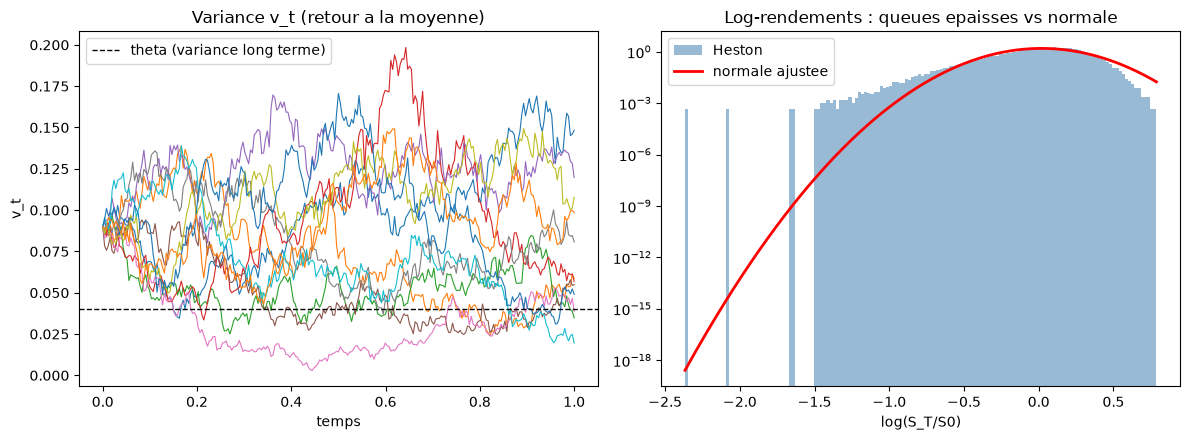

In [38]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
t = np.linspace(0, T, n+1)
for i in range(12):
    a1.plot(t, v[i], lw=0.8)
a1.axhline(theta, color="k", ls="--", lw=1, label="theta (variance long terme)")
a1.set_title("Variance v_t (retour a la moyenne)"); a1.set_xlabel("temps"); a1.set_ylabel("v_t"); a1.legend()

a2.hist(logret, bins=150, density=True, alpha=0.55, color="steelblue", label="Heston")
xg = np.linspace(logret.min(), logret.max(), 400)
a2.plot(xg, norm.pdf(xg, logret.mean(), logret.std()), "r", lw=2, label="normale ajustee")
a2.set_yscale("log"); a2.set_title("Log-rendements : queues epaisses vs normale")
a2.set_xlabel("log(S_T/S0)"); a2.legend()
plt.tight_layout(); plt.show()

### 3.2 The Heston benchmarks (notebook 08)

The classical numbers to beat under Heston. The structural fact that appears here is that the underlying alone cannot hedge the variance risk, so delta hedging plateaus at a floor that no amount of rebalancing gets under. That floor is the opening the network will exploit.

In [39]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)

In [40]:
def simulate_heston(S0, v0, mu, kappa, theta, xi, rho, T, n, m):
    dt = T/n; S = np.empty((m, n+1)); v = np.empty((m, n+1)); S[:,0]=S0; v[:,0]=v0
    for k in range(n):
        Z1 = rng.standard_normal(m); Zp = rng.standard_normal(m); Z2 = rho*Z1 + np.sqrt(1-rho**2)*Zp
        vk = np.maximum(v[:,k], 0.0)
        v[:,k+1] = np.maximum(v[:,k] + kappa*(theta-vk)*dt + xi*np.sqrt(vk)*np.sqrt(dt)*Z2, 0.0)
        S[:,k+1] = S[:,k]*np.exp((mu-0.5*vk)*dt + np.sqrt(vk)*np.sqrt(dt)*Z1)
    return S

def simulate_gbm(S0, mu, sig, T, n, m):
    dt = T/n; Z = rng.standard_normal((m, n)); inc = (mu-0.5*sig**2)*dt + sig*np.sqrt(dt)*Z
    return S0*np.exp(np.concatenate([np.zeros((m,1)), np.cumsum(inc, axis=1)], axis=1))

def cvar(pnl, a=0.95):
    loss = -pnl; return loss[loss >= np.quantile(loss, a)].mean()

def delta_hedge(S, K, T, r, hedge_vol, premium):
    m, n1 = S.shape; n = n1-1; dt = T/n; times = np.linspace(0, T, n1)
    cash = np.full(m, premium); sh = np.zeros(m)
    for k in range(n):
        tau = T - times[k]; dk = bs_delta(S[:,k], K, tau, r, hedge_vol); tr = dk - sh
        cash -= tr*S[:,k]; sh = dk; cash *= np.exp(r*dt)      # sans coûts ici
    return cash + sh*S[:,-1] - np.maximum(S[:,-1]-K, 0.0)

In [41]:
S0, K, mu, r, T = 100., 100., 0.05, 0.02, 1.0
v0, kappa, theta, xi, rho = 0.04, 2.0, 0.04, 0.3, -0.7   # vol moyenne ~20%, comme le GBM
sig_gbm = 0.20

Sr = simulate_heston(S0, v0, r, kappa, theta, xi, rho, T, 252, 80_000)   # sous r : risque-neutre
C_heston = np.exp(-r*T)*np.mean(np.maximum(Sr[:,-1]-K, 0))
sig_imp = brentq(lambda s: bs_price(S0, K, T, r, s) - C_heston, 1e-3, 2.0)
print(f"prix Heston (MC RN) = {C_heston:.3f}   vol implicite BS = {sig_imp:.4f}")

prix Heston (MC RN) = 8.689   vol implicite BS = 0.1942


n=  21 | CVaR Heston = 5.765 | CVaR GBM = 3.480
n=  63 | CVaR Heston = 4.624 | CVaR GBM = 1.994
n= 252 | CVaR Heston = 4.096 | CVaR GBM = 1.001


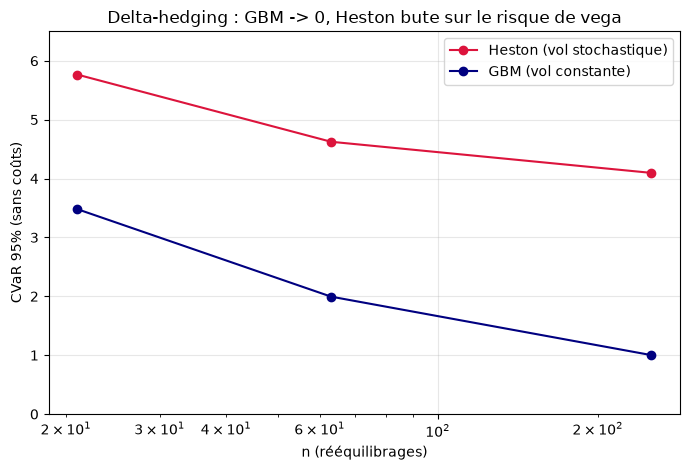

In [42]:
ns = [21, 63, 252]
cH, cG = [], []
for n in ns:
    SH = simulate_heston(S0, v0, mu, kappa, theta, xi, rho, T, n, 60_000)
    SG = simulate_gbm(S0, mu, sig_gbm, T, n, 60_000)
    cH.append(cvar(delta_hedge(SH, K, T, r, sig_imp, C_heston)))
    cG.append(cvar(delta_hedge(SG, K, T, r, sig_gbm, bs_price(S0, K, T, r, sig_gbm))))
    print(f"n={n:>4} | CVaR Heston = {cH[-1]:.3f} | CVaR GBM = {cG[-1]:.3f}")

plt.figure(figsize=(7, 4.8))
plt.plot(ns, cH, "o-", color="crimson", label="Heston (vol stochastique)")
plt.plot(ns, cG, "o-", color="navy", label="GBM (vol constante)")
plt.xscale("log"); plt.xlabel("n (rééquilibrages)"); plt.ylabel("CVaR 95% (sans coûts)")
plt.title("Delta-hedging : GBM -> 0, Heston bute sur le risque de vega")
plt.legend(); plt.grid(alpha=0.3); plt.ylim(0, 6.5); plt.tight_layout(); plt.show()

## Chapter 4. Deep hedging under Heston

### 4.1 No cost (notebook 09)

We give the network the instantaneous variance as an input, so it can react to the current volatility, and the state is now four numbers: log-moneyness, time to maturity, current position, and variance. Result: CVaR of 3.86 against 4.57 for delta hedging, about 16 percent better. The gain is exactly the part of the variance risk that a volatility-aware policy can manage and a fixed delta cannot.

In [43]:
import torch
import numpy as np
torch.manual_seed(0)
print("torch", torch.__version__)

torch 2.13.0


In [44]:
S0, K, mu, r, T = 100., 100., 0.05, 0.02, 1.0
v0, kappa, theta, xi, rho = 0.04, 2.0, 0.04, 0.3, -0.7   # vol ~20%
n, alpha = 63, 0.95
dt = T / n

def heston_step(S, v, drift, Z1, Z2):
    """un pas d'Euler Heston (troncature complète), en torch."""
    vk = torch.clamp(v, min=0.0)
    S2 = S * torch.exp((drift - 0.5*vk)*dt + torch.sqrt(vk)*np.sqrt(dt)*Z1)
    v2 = torch.clamp(v + kappa*(theta - vk)*dt + xi*torch.sqrt(vk)*np.sqrt(dt)*Z2, min=0.0)
    return S2, v2

# prime = prix Heston par Monte-Carlo risque-neutre (drift r), sans gradient
with torch.no_grad():
    m0 = 200_000
    S = torch.full((m0,), S0); v = torch.full((m0,), v0)
    for k in range(n):
        Z1 = torch.randn(m0); Z2 = rho*Z1 + np.sqrt(1-rho**2)*torch.randn(m0)
        S, v = heston_step(S, v, r, Z1, Z2)
    premium = float(np.exp(-r*T) * torch.clamp(S-K, min=0.0).mean())
print(f"prime = prix Heston (MC RN) = {premium:.3f}")

def cvar_ru(loss, w, alpha=0.95):
    return w + torch.mean(torch.relu(loss - w)) / (1.0 - alpha)

def bs_delta_torch(S, K, tau, r, s):
    d1 = (torch.log(S/K) + (r + 0.5*s**2)*tau) / (s*np.sqrt(tau))
    return 0.5*(1.0 + torch.erf(d1/np.sqrt(2.0)))

prime = prix Heston (MC RN) = 8.680


In [45]:
class HedgeNet(torch.nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(4, hidden), torch.nn.ReLU(),
            torch.nn.Linear(hidden, hidden), torch.nn.ReLU(),
            torch.nn.Linear(hidden, 1))
    def forward(self, x):
        return self.net(x).squeeze(-1)

def hedging_loss(net, w, m):
    S = torch.full((m,), S0); v = torch.full((m,), v0)
    cash = torch.full((m,), premium); delta_prev = torch.zeros(m)
    for k in range(n):
        tau = float(T - k*dt)
        feat = torch.stack([torch.log(S/K), torch.full((m,), tau), delta_prev, v], dim=1)  # (m,4)
        delta_k = net(feat)
        trade = delta_k - delta_prev
        cash = cash - trade*S                       # sans coûts
        # le marché avance d'un pas (drift physique mu)
        Z1 = torch.randn(m); Z2 = rho*Z1 + np.sqrt(1-rho**2)*torch.randn(m)
        S, v = heston_step(S, v, mu, Z1, Z2)
        cash = cash * np.exp(r*dt)
        delta_prev = delta_k
    pnl = cash + delta_prev*S - torch.clamp(S - K, min=0.0)
    return cvar_ru(-pnl, w, alpha)

In [46]:
net = HedgeNet()
w = torch.zeros(1, requires_grad=True)
opt = torch.optim.Adam(list(net.parameters()) + [w], lr=1e-3)

for it in range(2500):
    opt.zero_grad()
    loss = hedging_loss(net, w, 1024)
    loss.backward()
    opt.step()
    if it % 250 == 0:
        print(f"iter {it:4d}   CVaR (train) = {loss.item():.3f}")

iter    0   CVaR (train) = 113.512
iter  250   CVaR (train) = 13.731
iter  500   CVaR (train) = 11.887
iter  750   CVaR (train) = 10.031
iter 1000   CVaR (train) = 8.141
iter 1250   CVaR (train) = 6.580
iter 1500   CVaR (train) = 5.843
iter 1750   CVaR (train) = 4.863
iter 2000   CVaR (train) = 5.727
iter 2250   CVaR (train) = 4.985


In [47]:
sig_imp = 0.1942   # vol implicite BS du prix Heston (calculée brique 2)

with torch.no_grad():
    m = 100_000
    # --- réseau ---
    S = torch.full((m,), S0); v = torch.full((m,), v0)
    cash = torch.full((m,), premium); dprev = torch.zeros(m)
    for k in range(n):
        tau = float(T - k*dt)
        feat = torch.stack([torch.log(S/K), torch.full((m,), tau), dprev, v], dim=1)
        dk = net(feat); cash = cash - (dk-dprev)*S
        Z1 = torch.randn(m); Z2 = rho*Z1 + np.sqrt(1-rho**2)*torch.randn(m)
        S, v = heston_step(S, v, mu, Z1, Z2); cash = cash*np.exp(r*dt); dprev = dk
    pnl_net = cash + dprev*S - torch.clamp(S-K, min=0.0)

    # --- delta BS (benchmark), mêmes trajectoires impossibles a rejouer, on resimule ---
    S = torch.full((m,), S0); v = torch.full((m,), v0)
    cash = torch.full((m,), premium); dprev = torch.zeros(m)
    for k in range(n):
        tau = float(T - k*dt)
        dk = bs_delta_torch(S, K, tau, r, sig_imp); cash = cash - (dk-dprev)*S
        Z1 = torch.randn(m); Z2 = rho*Z1 + np.sqrt(1-rho**2)*torch.randn(m)
        S, v = heston_step(S, v, mu, Z1, Z2); cash = cash*np.exp(r*dt); dprev = dk
    pnl_bs = cash + dprev*S - torch.clamp(S-K, min=0.0)

def cvar(pnl, a=0.95):
    loss = -pnl; return loss[loss >= torch.quantile(loss, a)].mean().item()

print(f"CVaR réseau   = {cvar(pnl_net):.3f}")
print(f"CVaR delta BS = {cvar(pnl_bs):.3f}   (benchmark ~4.6)")

CVaR réseau   = 3.859
CVaR delta BS = 4.573   (benchmark ~4.6)


### 4.2 With cost (notebook 10)

The realistic case: frictions on top of incompleteness. The network reached 6.90, against 9.38 for pure delta and 8.05 for the best tuned band, about 14 percent better than the best classical hedge. This is the clean headline of the first half of the project: deep hedging wins where the problem is genuinely hard.

In [48]:
import torch
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq
torch.manual_seed(0)

In [49]:
S0, K, mu, r, T = 100., 100., 0.05, 0.02, 1.0
v0, kappa, theta, xi, rho = 0.04, 2.0, 0.04, 0.3, -0.7
n, cost, alpha = 63, 0.01, 0.95
dt = T/n
rng = np.random.default_rng(0)

def sim_heston_np(S0, v0, drift, T, n, m):
    dt = T/n; S=np.empty((m,n+1)); v=np.empty((m,n+1)); S[:,0]=S0; v[:,0]=v0
    for k in range(n):
        Z1=rng.standard_normal(m); Z2=rho*Z1+np.sqrt(1-rho**2)*rng.standard_normal(m)
        vk=np.maximum(v[:,k],0.0)
        v[:,k+1]=np.maximum(v[:,k]+kappa*(theta-vk)*dt+xi*np.sqrt(vk)*np.sqrt(dt)*Z2,0.0)
        S[:,k+1]=S[:,k]*np.exp((drift-0.5*vk)*dt+np.sqrt(vk)*np.sqrt(dt)*Z1)
    return S
def bs_price_np(S,K,tau,r,s):
    S=np.asarray(S,float); d1=(np.log(S/K)+(r+0.5*s**2)*tau)/(s*np.sqrt(tau)); d2=d1-s*np.sqrt(tau)
    return S*norm.cdf(d1)-K*np.exp(-r*tau)*norm.cdf(d2)
def bs_delta_np(S,K,tau,r,s):
    S=np.asarray(S,float); return norm.cdf((np.log(S/K)+(r+0.5*s**2)*tau)/(s*np.sqrt(tau)))
def cvar_np(pnl,a=0.95):
    loss=-pnl; return loss[loss>=np.quantile(loss,a)].mean()

premium = float(np.exp(-r*T)*np.mean(np.maximum(sim_heston_np(S0,v0,r,T,252,80_000)[:,-1]-K,0)))
sig_imp = brentq(lambda s: bs_price_np(S0,K,T,r,s)-premium, 1e-3, 2.0)
print(f"prime (prix Heston) = {premium:.3f}   vol implicite = {sig_imp:.4f}")

def band_hedge_np(S, band):
    m,n1=S.shape; nn=n1-1; times=np.linspace(0,T,n1); cash=np.full(m,premium); pos=np.zeros(m)
    for k in range(nn):
        tau=T-times[k]; tgt=bs_delta_np(S[:,k],K,tau,r,sig_imp); tr=np.where(np.abs(tgt-pos)>band,tgt-pos,0.0)
        cash-=tr*S[:,k]; cash-=cost*np.abs(tr)*S[:,k]; pos=pos+tr; cash*=np.exp(r*dt)
    return cash+pos*S[:,-1]-np.maximum(S[:,-1]-K,0.0)

SH = sim_heston_np(S0,v0,mu,T,n,80_000)
bands=[0.0,0.06,0.13,0.18,0.25]
cs=[cvar_np(band_hedge_np(SH,b)) for b in bands]
i=int(np.argmin(cs))
print("delta pur (band=0) CVaR =", round(cs[0],3))
print(f"bande optimale = {bands[i]:.2f}, CVaR = {cs[i]:.3f}")

prime (prix Heston) = 8.689   vol implicite = 0.1942
delta pur (band=0) CVaR = 9.386
bande optimale = 0.18, CVaR = 8.047


In [50]:
def heston_step_t(S, v, drift, Z1, Z2):
    vk = torch.clamp(v, min=0.0)
    return (S*torch.exp((drift-0.5*vk)*dt + torch.sqrt(vk)*np.sqrt(dt)*Z1),
            torch.clamp(v + kappa*(theta-vk)*dt + xi*torch.sqrt(vk)*np.sqrt(dt)*Z2, min=0.0))

def cvar_ru(loss, w, a=0.95):
    return w + torch.mean(torch.relu(loss - w))/(1.0 - a)

class HedgeNet(torch.nn.Module):
    def __init__(self, h=32):
        super().__init__()
        self.net = torch.nn.Sequential(torch.nn.Linear(4,h),torch.nn.ReLU(),
                                       torch.nn.Linear(h,h),torch.nn.ReLU(),torch.nn.Linear(h,1))
    def forward(self,x): return self.net(x).squeeze(-1)

def hedging_loss(net, w, m):
    S=torch.full((m,),S0); v=torch.full((m,),v0); cash=torch.full((m,),premium); dprev=torch.zeros(m)
    for k in range(n):
        tau=float(T-k*dt)
        feat=torch.stack([torch.log(S/K), torch.full((m,),tau), dprev, v], dim=1)
        dk=net(feat); tr=dk-dprev
        cash = cash - tr*S - cost*torch.abs(tr)*S          # <-- coûts ici
        Z1=torch.randn(m); Z2=rho*Z1+np.sqrt(1-rho**2)*torch.randn(m)
        S,v=heston_step_t(S,v,mu,Z1,Z2); cash=cash*np.exp(r*dt); dprev=dk
    pnl=cash+dprev*S-torch.clamp(S-K,min=0.0)
    return cvar_ru(-pnl, w, alpha)

In [51]:
net=HedgeNet(); w=torch.zeros(1,requires_grad=True)
opt=torch.optim.Adam(list(net.parameters())+[w], lr=1e-3)
for it in range(3000):
    opt.zero_grad(); loss=hedging_loss(net,w,2048); loss.backward(); opt.step()
    if it%300==0: print(f"iter {it:4d}  CVaR(train)={loss.item():.3f}")

iter    0  CVaR(train)=98.565
iter  300  CVaR(train)=29.727
iter  600  CVaR(train)=25.726
iter  900  CVaR(train)=24.911
iter 1200  CVaR(train)=20.447
iter 1500  CVaR(train)=18.667
iter 1800  CVaR(train)=18.362
iter 2100  CVaR(train)=16.314
iter 2400  CVaR(train)=13.640
iter 2700  CVaR(train)=12.833


In [52]:
def bs_delta_t(S,K,tau,r,s):
    d1=(torch.log(S/K)+(r+0.5*s**2)*tau)/(s*np.sqrt(tau)); return 0.5*(1+torch.erf(d1/np.sqrt(2)))

def rollout(policy, m):
    S=torch.full((m,),S0); v=torch.full((m,),v0); cash=torch.full((m,),premium); dprev=torch.zeros(m)
    for k in range(n):
        tau=float(T-k*dt); dk=policy(S,v,tau,dprev); tr=dk-dprev
        cash=cash-tr*S-cost*torch.abs(tr)*S
        Z1=torch.randn(m); Z2=rho*Z1+np.sqrt(1-rho**2)*torch.randn(m)
        S,v=heston_step_t(S,v,mu,Z1,Z2); cash=cash*np.exp(r*dt); dprev=dk
    return cash+dprev*S-torch.clamp(S-K,min=0.0)
def cvar_t(pnl,a=0.95):
    loss=-pnl; return loss[loss>=torch.quantile(loss,a)].mean().item()

net.eval()
with torch.no_grad():
    m=80_000
    pol_net = lambda S,v,tau,dp: net(torch.stack([torch.log(S/K),torch.full((len(S),),tau),dp,v],dim=1))
    pol_del = lambda S,v,tau,dp: bs_delta_t(S,K,tau,r,sig_imp)   # delta pur (band=0)
    print(f"CVaR réseau        = {cvar_t(rollout(pol_net,m)):.3f}")
    print(f"CVaR delta pur     = {cvar_t(rollout(pol_del,m)):.3f}   (~9.4)")
    print(f"CVaR bande optim.  ~ 8.05  (benchmark numpy ci-dessus)")

CVaR réseau        = 6.895
CVaR delta pur     = 9.384   (~9.4)
CVaR bande optim.  ~ 8.05  (benchmark numpy ci-dessus)


## Chapter 5. Pricing and tabulation

### 5.1 The Heston pricer by Fourier inversion (notebook 11)

To hedge with other options we first need to price them. This is the Heston characteristic function with Fourier inversion, in the two-probability form. We verified it against Monte Carlo across strikes, agreeing to a couple of cents, and checked that it reproduces the equity volatility smile.

In [53]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import brentq
from scipy.stats import norm
import matplotlib.pyplot as plt

In [54]:
S0, v0, r = 100., 0.04, 0.02
kappa, theta, xi, rho, T = 2.0, 0.04, 0.3, -0.7, 1.0
rng = np.random.default_rng(0)
def sim_ST(m, n=252):
    dt=T/n; S=np.full(m,S0); v=np.full(m,v0)
    for _ in range(n):
        Z1=rng.standard_normal(m); Z2=rho*Z1+np.sqrt(1-rho**2)*rng.standard_normal(m); vk=np.maximum(v,0)
        S=S*np.exp((r-0.5*vk)*dt+np.sqrt(vk)*np.sqrt(dt)*Z1); v=np.maximum(v+kappa*(theta-vk)*dt+xi*np.sqrt(vk)*np.sqrt(dt)*Z2,0)
    return S
ST=sim_ST(400_000)
for K in [90,100,110]:
    cf=heston_call(S0,v0,r,kappa,theta,xi,rho,T,K); mc=np.exp(-r*T)*np.mean(np.maximum(ST-K,0))
    print(f"K={K}: CF={cf:.4f}  MC={mc:.4f}")

K=90: CF=15.0953  MC=15.1109
K=100: CF=8.6860  MC=8.6991
K=110: CF=4.1900  MC=4.1977


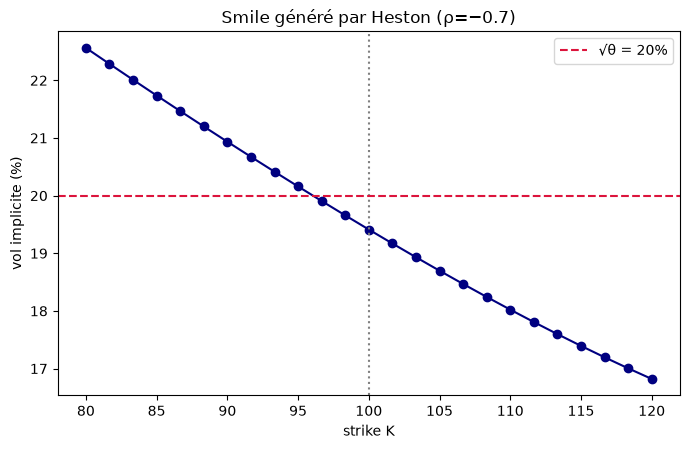

In [55]:
def bs_call(S,K,T,r,s):
    d1=(np.log(S/K)+(r+0.5*s**2)*T)/(s*np.sqrt(T)); d2=d1-s*np.sqrt(T)
    return S*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2)
Ks=np.linspace(80,120,25)
ivs=[brentq(lambda s: bs_call(S0,K,T,r,s)-heston_call(S0,v0,r,kappa,theta,xi,rho,T,K),1e-3,2.0) for K in Ks]
plt.figure(figsize=(7,4.6))
plt.plot(Ks,100*np.array(ivs),"o-",color="navy"); plt.axvline(S0,color="grey",ls=":")
plt.axhline(100*np.sqrt(theta),color="crimson",ls="--",label="√θ = 20%")
plt.xlabel("strike K"); plt.ylabel("vol implicite (%)"); plt.title("Smile généré par Heston (ρ=−0.7)")
plt.legend(); plt.tight_layout(); plt.show()

### 5.2 Tabulation and its convexity error (notebook 11b)

The Fourier pricer takes milliseconds per call, far too slow to run inside a hedging loop that needs it millions of times. So we tabulate it on a grid over spot, variance, and maturity, and interpolate. The interpolation error has a clean signature worth understanding: a call price is convex in spot, and linear interpolation draws a chord above a convex curve, so the interpolated price is biased slightly high, largest near the money where gamma is strongest, and exactly zero on the grid nodes. It shrinks like the square of the grid spacing. Because we use the same interpolator to value an option when we open and when we close it, the errors are consistent and mostly cancel in the hedging P&L.

In [56]:
import numpy as np
from scipy.integrate import quad
from scipy.interpolate import RegularGridInterpolator, interp1d
import matplotlib.pyplot as plt

# --- pricer Heston par fonction caracteristique (verifie au notebook 11) ---
r, kappa, theta, xi, rho = 0.02, 2.0, 0.04, 0.3, -0.7
K = 100.0


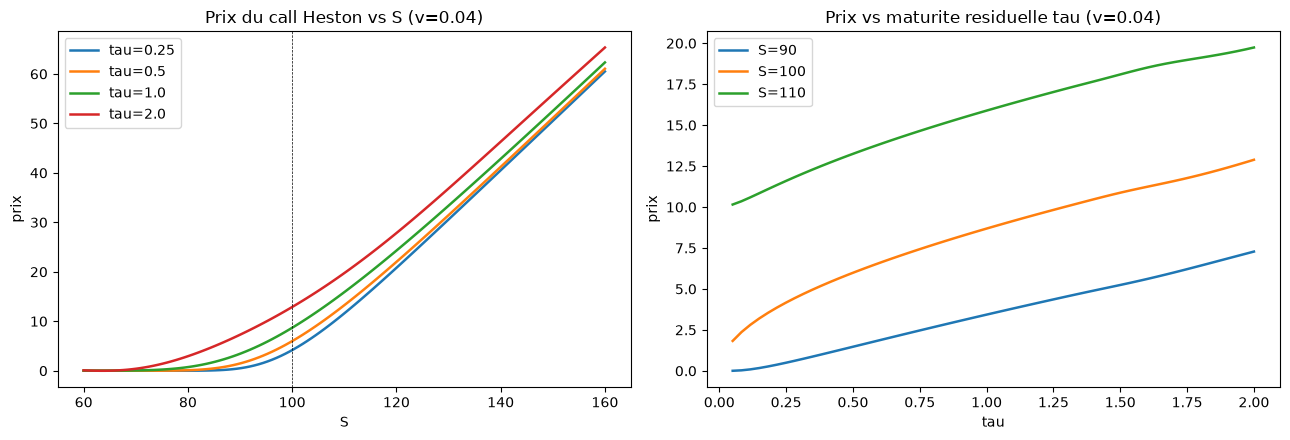

In [57]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

Sfine = np.linspace(60, 160, 120); v_ = 0.04
for tau in [0.25, 0.5, 1.0, 2.0]:
    C = [heston_call(S, v_, r, kappa, theta, xi, rho, tau, K) for S in Sfine]
    ax1.plot(Sfine, C, lw=1.8, label=f"tau={tau}")
ax1.axvline(K, color='k', lw=0.5, ls='--')
ax1.set_title("Prix du call Heston vs S (v=0.04)")
ax1.set_xlabel("S"); ax1.set_ylabel("prix"); ax1.legend()

taufine = np.linspace(0.05, 2.0, 60)
for S_ in [90, 100, 110]:
    C = [heston_call(S_, v_, r, kappa, theta, xi, rho, tau, K) for tau in taufine]
    ax2.plot(taufine, C, lw=1.8, label=f"S={S_}")
ax2.set_title("Prix vs maturite residuelle tau (v=0.04)")
ax2.set_xlabel("tau"); ax2.set_ylabel("prix"); ax2.legend()
fig.tight_layout(); plt.show()


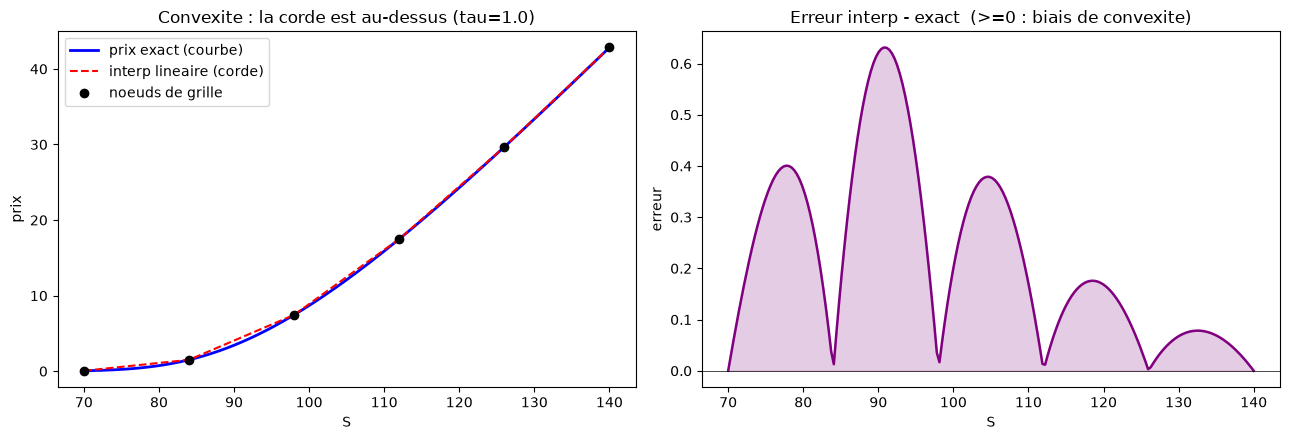

In [58]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
tau_, v_ = 1.0, 0.04

nodes = np.linspace(70, 140, 6)                                       # grille grossiere en S
Cn = np.array([heston_call(S, v_, r, kappa, theta, xi, rho, tau_, K) for S in nodes])
lin = interp1d(nodes, Cn)                                             # interpolation lineaire (corde)
Sfine = np.linspace(70, 140, 200)
Cex = np.array([heston_call(S, v_, r, kappa, theta, xi, rho, tau_, K) for S in Sfine])

ax1.plot(Sfine, Cex, 'b', lw=2, label="prix exact (courbe)")
ax1.plot(Sfine, lin(Sfine), 'r--', lw=1.5, label="interp lineaire (corde)")
ax1.plot(nodes, Cn, 'ko', ms=6, label="noeuds de grille")
ax1.set_title(f"Convexite : la corde est au-dessus (tau={tau_})")
ax1.set_xlabel("S"); ax1.set_ylabel("prix"); ax1.legend()

ax2.plot(Sfine, lin(Sfine) - Cex, 'purple', lw=1.8)
ax2.axhline(0, color='k', lw=0.5)
ax2.fill_between(Sfine, lin(Sfine) - Cex, 0, alpha=0.2, color='purple')
ax2.set_title("Erreur interp - exact  (>=0 : biais de convexite)")
ax2.set_xlabel("S"); ax2.set_ylabel("erreur")
fig.tight_layout(); plt.show()


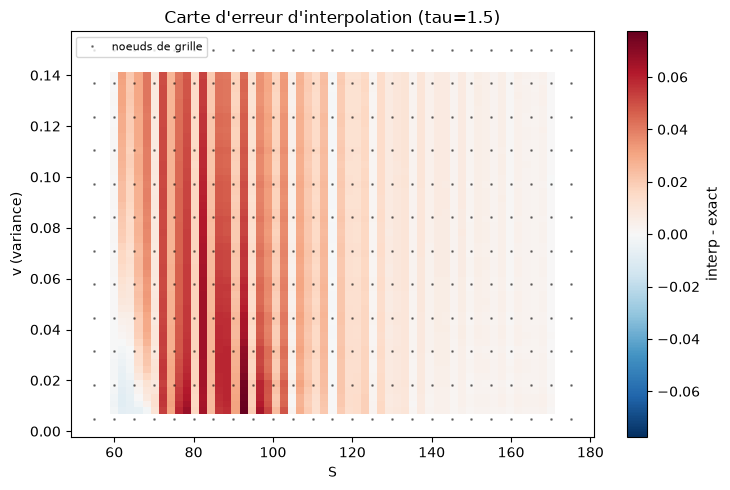

erreur abs max = 0.0774   moyenne = 0.0177


In [59]:
Sg = np.linspace(55, 175, 25); vg = np.linspace(0.005, 0.15, 12); tau_ = 1.5
coarse = np.array([[heston_call(S, v, r, kappa, theta, xi, rho, tau_, K) for v in vg] for S in Sg])
itp = RegularGridInterpolator((Sg, vg), coarse, bounds_error=False, fill_value=None)

Sf = np.linspace(60, 170, 55); vf = np.linspace(0.008, 0.14, 50)
SS, VV = np.meshgrid(Sf, vf, indexing='ij')
approx = itp(np.c_[SS.ravel(), VV.ravel()]).reshape(SS.shape)
exact = np.array([[heston_call(S, v, r, kappa, theta, xi, rho, tau_, K) for v in vf] for S in Sf])
err = approx - exact

fig, ax = plt.subplots(figsize=(7.5, 5))
im = ax.pcolormesh(Sf, vf, err.T, shading='auto', cmap='RdBu_r',
                   vmin=-abs(err).max(), vmax=abs(err).max())
ax.plot(np.repeat(Sg, len(vg)), np.tile(vg, len(Sg)), 'k.', ms=2, alpha=0.4, label="noeuds de grille")
fig.colorbar(im, label="interp - exact")
ax.set_title(f"Carte d'erreur d'interpolation (tau={tau_})")
ax.set_xlabel("S"); ax.set_ylabel("v (variance)"); ax.legend(loc='upper left', fontsize=8)
fig.tight_layout(); plt.show()
print(f"erreur abs max = {abs(err).max():.4f}   moyenne = {abs(err).mean():.4f}")


## Chapter 6. A second instrument (notebook 12)

Under Heston the underlying cannot touch the variance risk, so we add a second traded option, a longer-dated call, and let the network hold a position in both it and the underlying.

The insight that makes this tractable is that the market is exogenous: our trades do not move prices, so the paths and the hedging option's price along them do not depend on the network. We can therefore simulate everything once, tabulate the hedging option's price along each path, and train on frozen data, with the gradient flowing only through the network's actions. No need to backpropagate through a pricer.

The CVaR dropped to 2.45, against 6.54 for a classical delta-vega hedge. It looked like a triumph. It was also partly a trap, which the next chapter unpacks honestly.

In [60]:
import numpy as np
import torch
import time
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.interpolate import RegularGridInterpolator

torch.manual_seed(0)
rng = np.random.default_rng(0)

# --- parametres marche (identiques a tout le projet) ---
S0, K, mu, r, T1 = 100., 100., 0.05, 0.02, 1.0     # passif : call K=100, maturite T1=1
v0, kappa, theta, xi, rho = 0.04, 2.0, 0.04, 0.3, -0.7
Kh, T2 = 100., 2.0                                  # option de couverture : call Kh=100, maturite T2=2
n, cost, alpha = 63, 0.01, 0.95                     # 63 pas (~hebdo), cout 1%, CVaR 95%
dt = T1/n

# --- pricer Heston par fonction caracteristique (verifie au notebook 11) ---

In [61]:
def build_grid(Sg, vg, tg, Kstrike):
    """Tabule le prix Heston C(S, v, tau) sur la grille, pour un strike donne."""
    grid = np.zeros((len(Sg), len(vg), len(tg)))
    for i, S in enumerate(Sg):                       # boucle sur le prix
        for j, v in enumerate(vg):                   # boucle sur la variance
            for k, tau in enumerate(tg):             # boucle sur la maturite residuelle
                grid[i, j, k] = heston_call(S, v, r, kappa, theta, xi, rho, tau, Kstrike)
    return grid

Sg  = np.linspace(55, 175, 25)      # axe prix     : 25 noeuds
vg  = np.linspace(0.005, 0.15, 12)  # axe variance : 12 noeuds
tgO = np.linspace(1.0, 2.0, 13)     # maturite residuelle de la couverture : [1, 2]
tgL = np.linspace(0.01, 1.0, 15)    # maturite residuelle du passif        : [0.01, 1]

t0 = time.time()
gridO = build_grid(Sg, vg, tgO, Kh)                  # grille option de couverture (~50 s)
gridL = build_grid(Sg, vg, tgL, K)                   # grille passif            (~20 s)
print(f"grilles construites en {time.time()-t0:.0f} s")

# interpolateurs trilineaires : (S, v, tau) -> prix
Ointerp = RegularGridInterpolator((Sg, vg, tgO), gridO, bounds_error=False, fill_value=None)
Pinterp = RegularGridInterpolator((Sg, vg, tgL), gridL, bounds_error=False, fill_value=None)

premium = float(Pinterp([[S0, v0, T1]])[0])          # prime encaissee en vendant le passif
print(f"prime du passif (prix Heston) = {premium:.3f}")

grilles construites en 24 s
prime du passif (prix Heston) = 8.682


In [62]:
def sim_heston(S0, v0, drift, T, n, m):
    """Euler full-truncation. Renvoie (S, v) de forme (m, n+1)."""
    dt = T/n
    S = np.empty((m, n+1)); v = np.empty((m, n+1)); S[:,0] = S0; v[:,0] = v0
    for k in range(n):
        Z1 = rng.standard_normal(m)
        Z2 = rho*Z1 + np.sqrt(1-rho**2)*rng.standard_normal(m)   # correlation instantanee rho
        vk = np.maximum(v[:,k], 0.0)                              # full-truncation : v- = max(v,0)
        v[:,k+1] = np.maximum(v[:,k] + kappa*(theta-vk)*dt + xi*np.sqrt(vk*dt)*Z2, 0.0)
        S[:,k+1] = S[:,k]*np.exp((drift - 0.5*vk)*dt + np.sqrt(vk*dt)*Z1)
    return S, v

def price_along(S, v, interp, Kstrike, Tmat):
    """Prix de l'option (maturite Tmat) le long de la trajectoire : tau = Tmat - t."""
    m, n1 = S.shape; times = np.linspace(0, T1, n1)
    O = np.empty_like(S)
    for k in range(n1):
        tau = max(Tmat - times[k], 1e-3)
        O[:,k] = interp(np.c_[S[:,k], v[:,k], np.full(m, tau)])
    return O

m_tr, m_te = 100_000, 80_000
S_tr, v_tr = sim_heston(S0, v0, mu, T1, n, m_tr)
S_te, v_te = sim_heston(S0, v0, mu, T1, n, m_te)
O_tr = price_along(S_tr, v_tr, Ointerp, Kh, T2)     # prix couverture le long des trajectoires (train)
O_te = price_along(S_te, v_te, Ointerp, Kh, T2)     # idem (test)
print("paquets simules :", S_tr.shape, S_te.shape)
print(f"O couverture en t0 = {O_tr[0,0]:.3f}   |   O a l'echeance (moyen) = {O_tr[:,-1].mean():.3f}")


paquets simules : (100000, 64) (80000, 64)
O couverture en t0 = 12.886   |   O a l'echeance (moyen) = 15.165


In [63]:
hS_, hv_ = 1.0, 0.005    # pas des differences finies (en prix, en variance)
def greeks(interp, Sk, vk, tau):
    """Renvoie (prix, dP/dS, dP/dv) par differences finies centrees."""
    tau = np.full_like(Sk, tau)
    Pp  = interp(np.c_[Sk+hS_, vk, tau]); Pm = interp(np.c_[Sk-hS_, vk, tau])
    vm  = np.maximum(vk-hv_, 1e-4)
    Pvp = interp(np.c_[Sk, vk+hv_, tau]); Pvm = interp(np.c_[Sk, vm, tau])
    dS  = (Pp - Pm)/(2*hS_)
    dv  = (Pvp - Pvm)/(vk+hv_ - vm)
    return dS, dv

def cvar(pnl, a=0.95):
    loss = -pnl
    return loss[loss >= np.quantile(loss, a)].mean()

times = np.linspace(0, T1, n+1)

def classic_hedge(S, v, O, vega=True):
    m = S.shape[0]; cash = np.full(m, premium); posS = np.zeros(m); posO = np.zeros(m)
    for k in range(n):
        tauL = max(T1 - times[k], 0.01); tauO = T2 - times[k]
        PS, Pv = greeks(Pinterp, S[:,k], v[:,k], tauL)
        if vega:
            OS, Ov = greeks(Ointerp, S[:,k], v[:,k], tauO)
            tgtO = Pv/Ov                      # vega-neutre
            tgtS = PS - tgtO*OS               # delta-neutre residuel
            trO = tgtO - posO
            cash -= trO*O[:,k] + cost*np.abs(trO)*O[:,k]   # cout sur l'option
            posO = tgtO
        else:
            tgtS = PS
        trS = tgtS - posS
        cash -= trS*S[:,k] + cost*np.abs(trS)*S[:,k]       # cout sur le sous-jacent
        posS = tgtS; cash *= np.exp(r*dt)
    return cash + posS*S[:,-1] + posO*O[:,-1] - np.maximum(S[:,-1]-K, 0.0)

pnl_delta = classic_hedge(S_te, v_te, O_te, vega=False)
pnl_dv    = classic_hedge(S_te, v_te, O_te, vega=True)
print(f"CVaR delta pur (grecque Heston) = {cvar(pnl_delta):.3f}")
print(f"CVaR delta-vega classique       = {cvar(pnl_dv):.3f}")


CVaR delta pur (grecque Heston) = 8.800
CVaR delta-vega classique       = 6.542


In [64]:
def cvar_ru(loss, w, a=0.95):
    return w + torch.mean(torch.relu(loss - w))/(1.0 - a)

class HedgeNet2(torch.nn.Module):
    def __init__(self, h=48):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(6, h), torch.nn.ReLU(),
            torch.nn.Linear(h, h), torch.nn.ReLU(),
            torch.nn.Linear(h, 2))          # 2 sorties : (position sous-jacent, position option)
    def forward(self, x):
        return self.net(x)

# tenseurs de donnees (marche exogene => constantes, aucun gradient a travers eux)
St  = torch.tensor(S_tr, dtype=torch.float32)
vt  = torch.tensor(v_tr, dtype=torch.float32)
Ot  = torch.tensor(O_tr, dtype=torch.float32)

def hedging_loss(net, w, idx):
    """P&L couvert sur le sous-paquet idx, puis CVaR."""
    S = St[idx]; v = vt[idx]; O = Ot[idx]; m = S.shape[0]
    cash = torch.full((m,), premium); posS = torch.zeros(m); posO = torch.zeros(m)
    for k in range(n):
        tau = float(T1 - k*dt)
        feat = torch.stack([torch.log(S[:,k]/K), torch.full((m,), tau),
                            posS, posO, v[:,k], O[:,k]/S0], dim=1)
        a = net(feat); aS = a[:,0]; aO = a[:,1]              # positions cibles
        trS = aS - posS; trO = aO - posO
        cash = cash - trS*S[:,k] - cost*torch.abs(trS)*S[:,k]   # trade + cout sous-jacent
        cash = cash - trO*O[:,k] - cost*torch.abs(trO)*O[:,k]   # trade + cout option
        cash = cash*np.exp(r*dt)
        posS = aS; posO = aO
    pnl = cash + posS*S[:,-1] + posO*O[:,-1] - torch.clamp(S[:,-1]-K, min=0.0)
    return cvar_ru(-pnl, w, alpha)


In [65]:
net = HedgeNet2()
w   = torch.zeros(1, requires_grad=True)                       # variable auxiliaire du CVaR
opt = torch.optim.Adam(list(net.parameters()) + [w], lr=1e-3)

batch = 20_000; epochs = 400
for ep in range(epochs):
    idx = torch.randint(0, m_tr, (batch,))                    # mini-batch tire dans le paquet train
    loss = hedging_loss(net, w, idx)
    opt.zero_grad(); loss.backward(); opt.step()
    if (ep+1) % 50 == 0:
        print(f"epoch {ep+1:4d}   CVaR train (batch) = {loss.item():.3f}")


epoch   50   CVaR train (batch) = 29.420
epoch  100   CVaR train (batch) = 17.141
epoch  150   CVaR train (batch) = 14.553
epoch  200   CVaR train (batch) = 12.495
epoch  250   CVaR train (batch) = 10.076
epoch  300   CVaR train (batch) = 8.624
epoch  350   CVaR train (batch) = 7.585
epoch  400   CVaR train (batch) = 7.059


In [66]:
Ste = torch.tensor(S_te, dtype=torch.float32)
vte = torch.tensor(v_te, dtype=torch.float32)
Ote = torch.tensor(O_te, dtype=torch.float32)

def rollout_net(net):
    m = m_te; cash = torch.full((m,), premium); posS = torch.zeros(m); posO = torch.zeros(m)
    for k in range(n):
        tau = float(T1 - k*dt)
        feat = torch.stack([torch.log(Ste[:,k]/K), torch.full((m,), tau),
                            posS, posO, vte[:,k], Ote[:,k]/S0], dim=1)
        a = net(feat); aS = a[:,0]; aO = a[:,1]
        trS = aS - posS; trO = aO - posO
        cash = cash - trS*Ste[:,k] - cost*torch.abs(trS)*Ste[:,k]
        cash = cash - trO*Ote[:,k] - cost*torch.abs(trO)*Ote[:,k]
        cash = cash*np.exp(r*dt); posS = aS; posO = aO
    return (cash + posS*Ste[:,-1] + posO*Ote[:,-1] - torch.clamp(Ste[:,-1]-K, min=0.0)).detach().numpy()

net.eval()
with torch.no_grad():
    pnl_net = rollout_net(net)

print(f"CVaR delta pur          = {cvar(pnl_delta):.3f}")
print(f"CVaR delta-vega class.  = {cvar(pnl_dv):.3f}")
print(f"CVaR reseau (2 instr.)  = {cvar(pnl_net):.3f}")
print(f"rappel reseau 1 instr. (nb 10) ~ 6.90")


CVaR delta pur          = 8.800
CVaR delta-vega class.  = 6.542
CVaR reseau (2 instr.)  = 2.445
rappel reseau 1 instr. (nb 10) ~ 6.90


figure : 12_multi_instrument.png


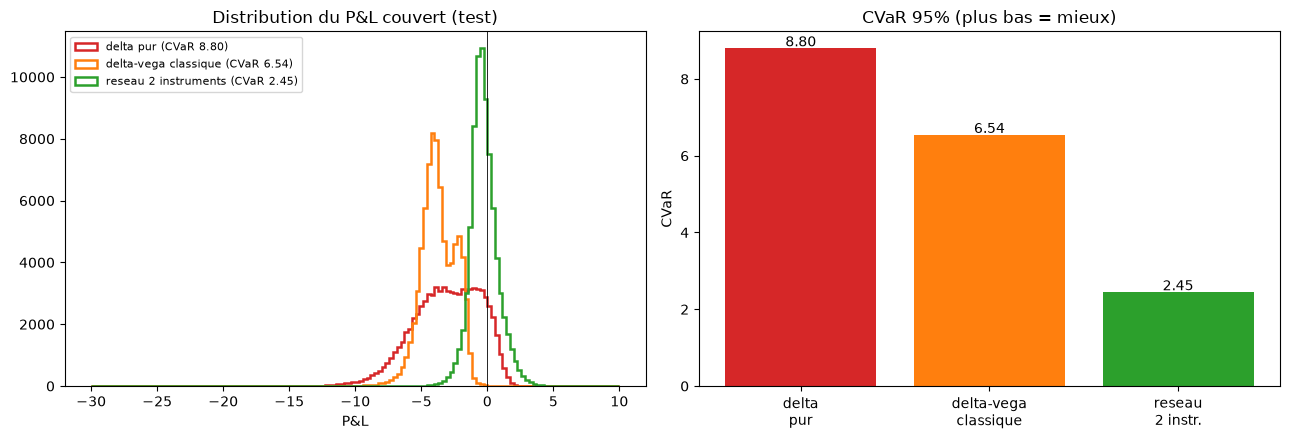

In [67]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

for pnl, lab, c in [(pnl_delta,'delta pur','tab:red'),
                    (pnl_dv,'delta-vega classique','tab:orange'),
                    (pnl_net,'reseau 2 instruments','tab:green')]:
    ax1.hist(pnl, bins=140, range=(-30,10), histtype='step', lw=1.8, label=f"{lab} (CVaR {cvar(pnl):.2f})", color=c)
ax1.axvline(0, color='k', lw=0.6); ax1.set_title("Distribution du P&L couvert (test)")
ax1.set_xlabel("P&L"); ax1.legend(fontsize=8)

labels = ['delta\npur','delta-vega\nclassique','reseau\n2 instr.']
vals = [cvar(pnl_delta), cvar(pnl_dv), cvar(pnl_net)]
ax2.bar(labels, vals, color=['tab:red','tab:orange','tab:green'])
for i,val in enumerate(vals): ax2.text(i, val+0.05, f"{val:.2f}", ha='center')
ax2.set_title("CVaR 95% (plus bas = mieux)"); ax2.set_ylabel("CVaR")
fig.tight_layout(); fig.savefig("12_multi_instrument.png", dpi=110)
print("figure : 12_multi_instrument.png")


## Chapter 7 and 8. The reckoning, then the barrier (notebook 13)

This notebook holds two of the most instructive moments in the project.

**The reckoning (part A).** Distrusting our own good number, we looked at what the network actually held over time and found it had learned a nearly static calendar spread, not a clever dynamic policy. A purely static hedge, buy one option once and never trade, already reaches 3.90. And the classical delta-vega benchmark at 6.54 is beaten by simply holding one option, because it rebalances two greeks every step and bleeds the cost. So most of the 2.45 came from adding an instrument that carries vega, not from dynamics, and the genuine value of the dynamic policy is 3.90 down to 2.45, not 6.54 down to 2.45. Unpacking your own result is worth more than the headline.

**The barrier, and the debugging that hurt (part B).** To show dynamics really mattering we moved to an up-and-out call, worthless if the spot ever touches a barrier. The textbook delta hedge of it is worse than doing nothing (26.5 against 20.7), a static vanilla reaches 6.4, and the deep hedger reaches 5.0, but only after a fight.

The network refused to train, coming back worse than the static hedge three times: 10.36, 10.69, 11.52. We worked through it in three moves. We tried residual hedging, learning a correction around a static anchor with the last layer initialized to zero so the policy starts at the static hedge, and it still failed. We tried fresh Monte Carlo paths every epoch to kill overfitting, and it still failed. The real culprit was the loss: the Rockafellar-Uryasev auxiliary variable barely moves under Adam, which normalizes each step by the gradient magnitude, so it stayed near zero and the objective quietly became the mean loss instead of the tail. For a vanilla the two are close and it never showed; for a barrier they diverge and the tail got worse while training reported progress. Switching to the direct empirical CVaR, the mean of the losses beyond the sample quantile, fixed it. The lesson: optimizing a CVaR is not the same as writing the CVaR formula and pointing an optimizer at it.

In [68]:
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.interpolate import RegularGridInterpolator
from scipy.stats import norm

S0, K, mu, r, T1 = 100., 100., 0.05, 0.02, 1.0
v0, kappa, theta, xi, rho = 0.04, 2.0, 0.04, 0.3, -0.7
Kh, T2 = 100., 2.0
n, cost, alpha = 63, 0.01, 0.95
dt = T1/n

def build_grid(Sg, vg, tg, Kstrike):
    G = np.zeros((len(Sg), len(vg), len(tg)))
    for i, S in enumerate(Sg):
        for j, v in enumerate(vg):
            for k, tau in enumerate(tg):
                G[i, j, k] = heston_call(S, v, r, kappa, theta, xi, rho, tau, Kstrike)
    return G

Sg = np.linspace(55, 175, 25); vg = np.linspace(0.005, 0.15, 12)
tgO = np.linspace(1.0, 2.0, 13); tgL = np.linspace(0.01, 1.0, 15)
t0 = time.time()
Ointerp = RegularGridInterpolator((Sg, vg, tgO), build_grid(Sg, vg, tgO, Kh), bounds_error=False, fill_value=None)
Pinterp = RegularGridInterpolator((Sg, vg, tgL), build_grid(Sg, vg, tgL, K),  bounds_error=False, fill_value=None)
print(f"grilles construites en {time.time()-t0:.0f} s")

premium = float(Pinterp([[S0, v0, T1]])[0]); O0 = float(Ointerp([[S0, v0, T2]])[0])

def sim_heston(m, drift, seed):
    rng = np.random.default_rng(seed)
    S = np.empty((m, n+1)); v = np.empty((m, n+1)); S[:,0] = S0; v[:,0] = v0
    for k in range(n):
        Z1 = rng.standard_normal(m); Z2 = rho*Z1 + np.sqrt(1-rho**2)*rng.standard_normal(m)
        vk = np.maximum(v[:,k], 0.0)
        v[:,k+1] = np.maximum(v[:,k] + kappa*(theta-vk)*dt + xi*np.sqrt(vk*dt)*Z2, 0.0)
        S[:,k+1] = S[:,k]*np.exp((drift - 0.5*vk)*dt + np.sqrt(vk*dt)*Z1)
    return S, v
def cvar(pnl, a=0.95):
    loss = -pnl; return loss[loss >= np.quantile(loss, a)].mean()

print(f"prime passif = {premium:.3f}   prix option couverture = {O0:.3f}")


grilles construites en 24 s
prime passif = 8.682   prix option couverture = 12.886


In [69]:
hS_, hv_ = 1.0, 0.005
def greeks(interp, Sk, vk, tau):
    tau = np.full_like(Sk, tau); vm = np.maximum(vk-hv_, 1e-4)
    dS = (interp(np.c_[Sk+hS_, vk, tau]) - interp(np.c_[Sk-hS_, vk, tau]))/(2*hS_)
    dv = (interp(np.c_[Sk, vk+hv_, tau]) - interp(np.c_[Sk, vm, tau]))/(vk+hv_-vm)
    return dS, dv

m = 80_000; S, v = sim_heston(m, mu, 7); times = np.linspace(0, T1, n+1)
Ofin = Ointerp(np.c_[S[:,-1], v[:,-1], np.full(m, T2-T1)]); payoff = np.maximum(S[:,-1]-K, 0.)

# 1) ne rien faire
cvar_none = cvar(premium*np.exp(r*T1) - payoff)

# 2) statique : sous-jacent seul, h actions tenues, h optimise
best = min((cvar((premium-h*S0-cost*h*S0)*np.exp(r*T1) + h*S[:,-1] - payoff), h) for h in np.linspace(0,1,21))
cvar_stat_S = best[0]

# 3) statique : 1 option tenue, h optimise
best = min((cvar((premium-h*O0-cost*h*O0)*np.exp(r*T1) + h*Ofin - payoff), h) for h in np.linspace(0,1.4,29))
cvar_stat_O, h_opt = best

# 4) delta-vega, rebalancement a chaque pas (+ variante avec bande de non-trading)
def dv_hedge(bandS, bandO):
    cash = np.full(m, premium); posS = np.zeros(m); posO = np.zeros(m)
    for k in range(n):
        tauL = max(T1-times[k], 0.01); tauO = T2-times[k]
        PS, Pv = greeks(Pinterp, S[:,k], v[:,k], tauL); OS, Ov = greeks(Ointerp, S[:,k], v[:,k], tauO)
        tO = Pv/Ov; tS = PS - tO*OS; Ok = Ointerp(np.c_[S[:,k], v[:,k], np.full(m, tauO)])
        trO = np.where(np.abs(tO-posO) > bandO, tO-posO, 0.); cash -= trO*Ok + cost*np.abs(trO)*Ok; posO += trO
        trS = np.where(np.abs(tS-posS) > bandS, tS-posS, 0.); cash -= trS*S[:,k] + cost*np.abs(trS)*S[:,k]; posS += trS
        cash *= np.exp(r*dt)
    return cvar(cash + posS*S[:,-1] + posO*Ofin - payoff)
cvar_dv      = dv_hedge(0.0, 0.0)
cvar_dv_band = dv_hedge(0.08, 0.10)

print(f"{'ne rien faire':38s} {cvar_none:7.2f}")
print(f"{'statique sous-jacent seul':38s} {cvar_stat_S:7.2f}")
print(f"{'delta-vega continu':38s} {cvar_dv:7.2f}")
print(f"{'delta-vega avec bande (cost-aware)':38s} {cvar_dv_band:7.2f}")
print(f"{'statique 1 option (h=%.2f)'%h_opt:38s} {cvar_stat_O:7.2f}")
print(f"{'reseau 2 instruments (notebook 12)':38s} {2.45:7.2f}")


ne rien faire                            35.02
statique sous-jacent seul                16.08
delta-vega continu                        6.54
delta-vega avec bande (cost-aware)        5.81
statique 1 option (h=0.95)                3.90
reseau 2 instruments (notebook 12)        2.45


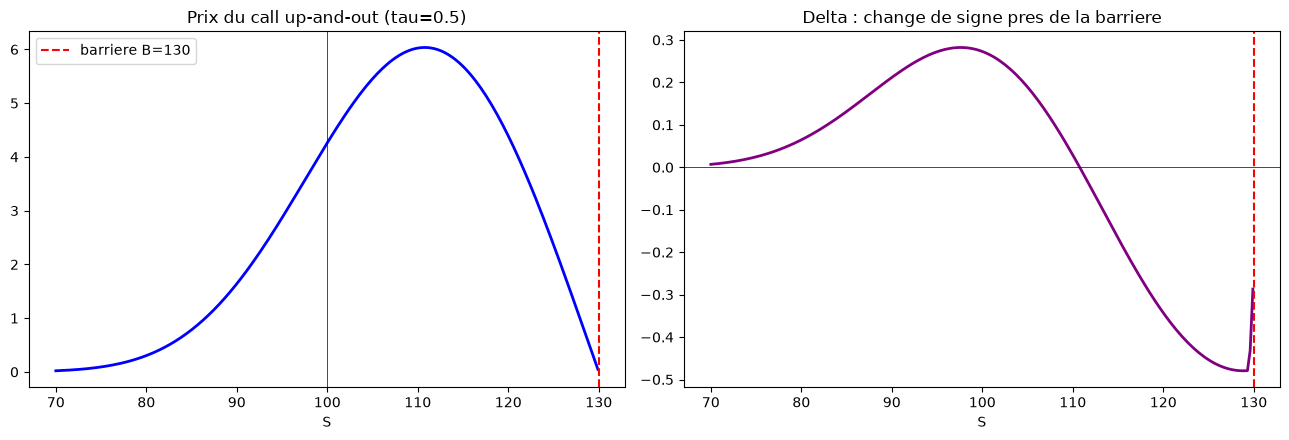

In [70]:
Bar = 130.0; sig_imp = 0.194     # barriere, et vol implicite ATM (pour la formule BS)

Sgrid = np.linspace(70, 129.9, 200)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(Sgrid, bs_uo_call(Sgrid, K, Bar, 0.5, r, sig_imp), 'b', lw=2)
ax1.axvline(Bar, color='r', ls='--', label='barriere B=130'); ax1.axvline(K, color='k', lw=0.5)
ax1.set_title("Prix du call up-and-out (tau=0.5)"); ax1.set_xlabel("S"); ax1.legend()
ax2.plot(Sgrid, bs_uo_delta(Sgrid, K, Bar, 0.5, r, sig_imp), 'purple', lw=2)
ax2.axhline(0, color='k', lw=0.5); ax2.axvline(Bar, color='r', ls='--')
ax2.set_title("Delta : change de signe pres de la barriere"); ax2.set_xlabel("S")
fig.tight_layout(); plt.show()


In [71]:
# prime up-and-out sous Heston (MC risque-neutre)
Sq, _ = sim_heston(200_000, r, 1)
knq = (Sq.max(axis=1) >= Bar)
prem_bar = float(np.exp(-r*T1)*np.where(~knq, np.maximum(Sq[:,-1]-K, 0.), 0.).mean())
print(f"prime up-and-out (Heston, B=130) = {prem_bar:.3f}   proba de knock-out = {knq.mean():.1%}")

# trajectoires reelles + statut 'vivant' (1 tant que la barriere n'a jamais ete touchee)
alive = np.cumprod((S < Bar).astype(float), axis=1)
payoff_bar = np.where(alive[:,-1] > 0, np.maximum(S[:,-1]-K, 0.), 0.)

cvar_bar_none = cvar(prem_bar*np.exp(r*T1) - payoff_bar)

# delta hedge classique BS-barriere : cible = delta * vivant (on liquide si knock)
cash = np.full(m, prem_bar); posS = np.zeros(m)
for k in range(n):
    tau = max(T1-times[k], 1e-3)
    tgt = bs_uo_delta(S[:,k], K, Bar, tau, r, sig_imp)*alive[:,k]
    tr = tgt - posS; cash -= tr*S[:,k] + cost*np.abs(tr)*S[:,k]; posS = tgt; cash *= np.exp(r*dt)
cvar_bar_delta = cvar(cash + posS*S[:,-1] - payoff_bar)

# statique : 1 vanille (2 ans) tenu, h optimise
best = min((cvar((prem_bar-h*O0-cost*abs(h)*O0)*np.exp(r*T1) + h*Ofin - payoff_bar), h) for h in np.linspace(-0.2,1.2,29))
cvar_bar_statO, h_bar = best

print(f"{'ne rien faire':34s} {cvar_bar_none:7.2f}")
print(f"{'delta hedge BS-barriere (dynamique)':34s} {cvar_bar_delta:7.2f}")
print(f"{'statique 1 vanille (h=%.2f)'%h_bar:34s} {cvar_bar_statO:7.2f}")


prime up-and-out (Heston, B=130) = 5.467   proba de knock-out = 10.2%
ne rien faire                        20.69
delta hedge BS-barriere (dynamique)   26.45
statique 1 vanille (h=0.90)           6.44


In [72]:
import torch
torch.manual_seed(0)

def price_along(S, v, interp, Tmat):
    m, n1 = S.shape; tt = np.linspace(0, T1, n1); O = np.empty_like(S)
    for k in range(n1):
        O[:,k] = interp(np.c_[S[:,k], v[:,k], np.full(m, max(Tmat-tt[k], 1e-3))])
    return O

def make_batch(m, seed):
    """Un lot Heston FRAIS + prix option + statut vivant, en tenseurs (constantes)."""
    Sb, vb = sim_heston(m, mu, seed)
    Ob = price_along(Sb, vb, Ointerp, T2)
    Ab = np.cumprod((Sb < Bar).astype(np.float32), axis=1)
    return (torch.tensor(Sb, dtype=torch.float32), torch.tensor(vb, dtype=torch.float32),
            torch.tensor(Ob, dtype=torch.float32), torch.tensor(Ab, dtype=torch.float32))

# jeu de test FIXE (jamais vu a l'entrainement puisque les lots train sont regeneres)
S_te2, v_te2 = sim_heston(80_000, mu, 200)
Ste = torch.tensor(S_te2, dtype=torch.float32); vte = torch.tensor(v_te2, dtype=torch.float32)
Ote = torch.tensor(price_along(S_te2, v_te2, Ointerp, T2), dtype=torch.float32)
Ate = torch.tensor(np.cumprod((S_te2 < Bar).astype(np.float32), axis=1), dtype=torch.float32)

def cvar_torch(L, a=0.95):
    """CVaR empirique direct : moyenne des pertes au-dela du quantile a. Cible la QUEUE."""
    var = torch.quantile(L, a)
    return L[L >= var].mean()

H0 = 0.90   # ancre statique (vanille)
class BarrierNet(torch.nn.Module):
    def __init__(self, h=64):
        super().__init__()
        self.net = torch.nn.Sequential(torch.nn.Linear(8, h), torch.nn.ReLU(),
                                       torch.nn.Linear(h, h), torch.nn.ReLU(),
                                       torch.nn.Linear(h, 2))
        torch.nn.init.zeros_(self.net[-1].weight); torch.nn.init.zeros_(self.net[-1].bias)
    def forward(self, x): return self.net(x)

def positions(net, feat):
    a = net(feat)
    return a[:,0], H0 + a[:,1]      # (sous-jacent autour de 0, option autour de H0)

def hedge_pnl(net, S, v, O, A):
    m = S.shape[0]; cash = torch.full((m,), prem_bar); posS = torch.zeros(m); posO = torch.zeros(m)
    for k in range(n):
        tau = float(T1 - k*dt)
        feat = torch.stack([torch.log(S[:,k]/K), torch.full((m,), tau), posS, posO,
                            v[:,k], O[:,k]/S0, (Bar - S[:,k])/S0, A[:,k]], dim=1)
        tgS, tgO = positions(net, feat); trS = tgS-posS; trO = tgO-posO
        cash = cash - trS*S[:,k] - cost*torch.abs(trS)*S[:,k]
        cash = cash - trO*O[:,k] - cost*torch.abs(trO)*O[:,k]
        cash = cash*np.exp(r*dt); posS = tgS; posO = tgO
    payoff = torch.clamp(S[:,-1]-K, min=0.0)*A[:,-1]
    return cash + posS*S[:,-1] + posO*O[:,-1] - payoff

In [73]:
net = BarrierNet()
opt = torch.optim.Adam(net.parameters(), lr=5e-4)
sched = torch.optim.lr_scheduler.StepLR(opt, step_size=250, gamma=0.4)

# CONTROLE : le reseau a l'init = ancre statique (0.9 vanille) => doit donner ~6.4
net.eval()
with torch.no_grad():
    c0 = cvar(hedge_pnl(net, Ste, vte, Ote, Ate).numpy())
net.train()
print(f"CVaR test a l'init = {c0:.3f}   (doit valoir ~ statique {cvar_bar_statO:.2f})")

batch, epochs = 20_000, 700
for ep in range(epochs):
    Sb, vb, Ob, Ab = make_batch(batch, seed=1000+ep)          # lot Heston FRAIS
    loss = cvar_torch(-hedge_pnl(net, Sb, vb, Ob, Ab))         # CVaR empirique direct
    opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    if (ep+1) % 50 == 0:
        net.eval()
        with torch.no_grad():
            cte = cvar(hedge_pnl(net, Ste, vte, Ote, Ate).numpy())
        net.train()
        print(f"epoch {ep+1:4d}   CVaR train = {loss.item():6.3f}   CVaR test = {cte:6.3f}")

CVaR test a l'init = 6.449   (doit valoir ~ statique 6.44)
epoch   50   CVaR train =  5.857   CVaR test =  5.850
epoch  100   CVaR train =  5.621   CVaR test =  5.613
epoch  150   CVaR train =  5.464   CVaR test =  5.461
epoch  200   CVaR train =  5.288   CVaR test =  5.301
epoch  250   CVaR train =  5.136   CVaR test =  5.150
epoch  300   CVaR train =  5.095   CVaR test =  5.109
epoch  350   CVaR train =  5.075   CVaR test =  5.078
epoch  400   CVaR train =  5.038   CVaR test =  5.046
epoch  450   CVaR train =  5.004   CVaR test =  5.021
epoch  500   CVaR train =  4.981   CVaR test =  5.000
epoch  550   CVaR train =  4.995   CVaR test =  4.990
epoch  600   CVaR train =  4.985   CVaR test =  4.981
epoch  650   CVaR train =  4.957   CVaR test =  4.973
epoch  700   CVaR train =  4.944   CVaR test =  4.965


In [74]:
net.eval()
with torch.no_grad():
    pnl_barnet = hedge_pnl(net, Ste, vte, Ote, Ate).numpy()
print(f"{'ne rien faire':34s} {cvar_bar_none:7.2f}")
print(f"{'delta hedge BS-barriere':34s} {cvar_bar_delta:7.2f}")
print(f"{'statique 1 vanille':34s} {cvar_bar_statO:7.2f}")
print(f"{'reseau residuel (barriere)':34s} {cvar(pnl_barnet):7.2f}")

ne rien faire                        20.69
delta hedge BS-barriere              26.45
statique 1 vanille                    6.44
reseau residuel (barriere)            4.96


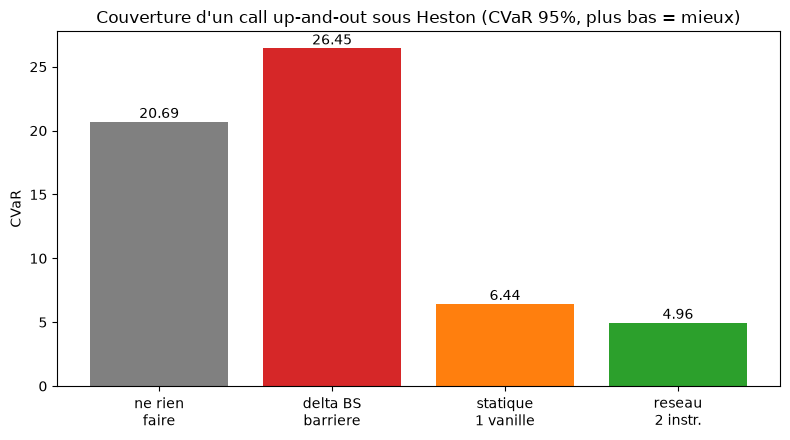

In [75]:
fig, ax = plt.subplots(figsize=(8,4.5))
labels = ['ne rien\nfaire','delta BS\nbarriere','statique\n1 vanille','reseau\n2 instr.']
vals = [cvar_bar_none, cvar_bar_delta, cvar_bar_statO, cvar(pnl_barnet)]
ax.bar(labels, vals, color=['gray','tab:red','tab:orange','tab:green'])
for i,val in enumerate(vals): ax.text(i, val+0.3, f"{val:.2f}", ha='center')
ax.set_title("Couverture d'un call up-and-out sous Heston (CVaR 95%, plus bas = mieux)")
ax.set_ylabel("CVaR"); fig.tight_layout(); plt.show()


## Chapter 9. Robustness to model misspecification

### 9.1 The null result (notebook 14)

The obvious challenge to a network trained in a simulator is whether it overfits that simulator. We trained on one set of Heston parameters and tested, with no retraining, on stressed markets: higher vol-of-vol, different correlation, a higher volatility regime.

The network stayed robust, beating the classical hedge in every scenario, and domain randomization added nothing. Our fragility hypothesis was wrong, and understanding why was the prize: the vanilla's optimal policy is a smooth function of the state it observes, including the current variance, and the parameters change the difficulty of the problem, not the shape of the optimal action. There was nothing to overfit.

In [76]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.stats import norm
from scipy.optimize import brentq

torch.manual_seed(0)
S0, K, mu, r, T = 100., 100., 0.05, 0.02, 1.0
n, cost, alpha = 63, 0.01, 0.95; dt = T/n

def cvar(p,a=0.95): l=-p; return l[l>=np.quantile(l,a)].mean()

# scenarios de marche
P0 = (0.04, 2.0, 0.04, 0.3, -0.7)          # in-model (entrainement)
scen = {'P0 in-model':                P0,
        'S1 xi=0.6 (vol-of-vol x2)':  (0.04, 2.0, 0.04, 0.6, -0.7),
        'S2 vol 30% (theta=v0=0.09)': (0.09, 2.0, 0.09, 0.3, -0.7),
        'S3 rho=-0.3 (moins skew)':   (0.04, 2.0, 0.04, 0.3, -0.3),
        'S4 crash rho=-0.9 xi=0.5':   (0.04, 2.0, 0.04, 0.5, -0.9)}
prem0 = heston_call(S0, *[P0[0], r, P0[1], P0[2], P0[3], P0[4]], T, K)
print(f"prime in-model = {prem0:.3f}")


prime in-model = 8.686


In [77]:
def sim_np(par, m, seed):
    v0, kappa, theta, xi, rho = par; rng = np.random.default_rng(seed)
    S = np.empty((m, n+1)); v = np.empty((m, n+1)); S[:,0] = S0; v[:,0] = v0
    for k in range(n):
        Z1 = rng.standard_normal(m); Z2 = rho*Z1 + np.sqrt(1-rho**2)*rng.standard_normal(m)
        vk = np.maximum(v[:,k], 0.)
        v[:,k+1] = np.maximum(v[:,k] + kappa*(theta-vk)*dt + xi*np.sqrt(vk*dt)*Z2, 0.)
        S[:,k+1] = S[:,k]*np.exp((mu - 0.5*vk)*dt + np.sqrt(vk*dt)*Z1)
    return S, v

def band_hedge(S, premium, sig, band=0.13):
    m = S.shape[0]; times = np.linspace(0, T, n+1); cash = np.full(m, premium); pos = np.zeros(m)
    for k in range(n):
        tau = max(T-times[k], 1e-3); tgt = bs_delta(S[:,k], K, tau, r, sig)
        tr = np.where(np.abs(tgt-pos) > band, tgt-pos, 0.); cash -= tr*S[:,k] + cost*np.abs(tr)*S[:,k]; pos += tr; cash *= np.exp(r*dt)
    return cash + pos*S[:,-1] - np.maximum(S[:,-1]-K, 0.)

classic = {}
for name, par in scen.items():
    prem = heston_call(S0, *[par[0], r, par[1], par[2], par[3], par[4]], T, K)
    sig = brentq(lambda s: bs_price(S0, K, T, r, s) - prem, 1e-3, 2.0)
    S, _ = sim_np(par, 60_000, 7)
    classic[name] = (prem, cvar(band_hedge(S, prem, sig)))
    print(f"{name:28s} prime={prem:6.3f}  vol_imp={sig:.3f}  CVaR classique={classic[name][1]:6.3f}")


P0 in-model                  prime= 8.686  vol_imp=0.194  CVaR classique= 7.996
S1 xi=0.6 (vol-of-vol x2)    prime= 8.137  vol_imp=0.180  CVaR classique=11.788
S2 vol 30% (theta=v0=0.09)   prime=12.570  vol_imp=0.294  CVaR classique= 8.778
S3 rho=-0.3 (moins skew)     prime= 8.716  vol_imp=0.195  CVaR classique= 8.989
S4 crash rho=-0.9 xi=0.5     prime=10.768  vol_imp=0.247  CVaR classique= 5.149


In [78]:
def heston_paths_t(par, m):
    v0, kappa, theta, xi, rho = par
    S = torch.full((m,), S0); v = torch.full((m,), float(v0)); Ss = [S]; vs = [v]
    for k in range(n):
        Z1 = torch.randn(m); Z2 = rho*Z1 + np.sqrt(1-rho**2)*torch.randn(m)
        vk = torch.clamp(v, min=0.)
        v = torch.clamp(v + kappa*(theta-vk)*dt + xi*torch.sqrt(vk*dt)*Z2, min=0.)
        S = S*torch.exp((mu - 0.5*vk)*dt + torch.sqrt(vk*dt)*Z1)
        Ss.append(S); vs.append(v)
    return torch.stack(Ss, 1), torch.stack(vs, 1)

def cvar_torch(L, a=0.95):
    var = torch.quantile(L, a); return L[L >= var].mean()

class HedgeNet(torch.nn.Module):
    def __init__(self, h=32):
        super().__init__()
        self.net = torch.nn.Sequential(torch.nn.Linear(4, h), torch.nn.ReLU(),
                                       torch.nn.Linear(h, h), torch.nn.ReLU(), torch.nn.Linear(h, 1))
    def forward(self, x): return self.net(x).squeeze(-1)

def hedge_cvar(net, S, v, premium):
    m = S.shape[0]; cash = torch.full((m,), premium); pos = torch.zeros(m)
    for k in range(n):
        tau = float(T - k*dt)
        feat = torch.stack([torch.log(S[:,k]/K), torch.full((m,), tau), pos, v[:,k]], dim=1)
        d = net(feat); tr = d - pos
        cash = cash - tr*S[:,k] - cost*torch.abs(tr)*S[:,k]; cash = cash*np.exp(r*dt); pos = d
    pnl = cash + pos*S[:,-1] - torch.clamp(S[:,-1]-K, min=0.0)
    return pnl

def train(sampler, epochs=400, m=20_000, lr=1e-3):
    net = HedgeNet(); opt = torch.optim.Adam(net.parameters(), lr=lr)
    for ep in range(epochs):
        par = sampler()
        S, v = heston_paths_t(par, m)
        loss = cvar_torch(-hedge_cvar(net, S.detach(), v.detach(), prem0))
        opt.zero_grad(); loss.backward(); opt.step()
        if (ep+1) % 100 == 0: print(f"  epoch {ep+1}  CVaR train = {loss.item():.3f}")
    return net

print("entrainement sur P0 ..."); net_p0 = train(lambda: P0)


entrainement sur P0 ...
  epoch 100  CVaR train = 9.760
  epoch 200  CVaR train = 6.441
  epoch 300  CVaR train = 6.301
  epoch 400  CVaR train = 6.309


In [79]:
def eval_net(net, par, prem, m=60_000, seed=7):
    Snp, vnp = sim_np(par, m, seed)
    with torch.no_grad():
        pnl = hedge_cvar(net, torch.tensor(Snp, dtype=torch.float32),
                         torch.tensor(vnp, dtype=torch.float32), prem).numpy()
    return cvar(pnl)

print(f"{'scenario':28s} {'classique':>10s} {'net P0':>9s}")
res_p0 = {}
for name, par in scen.items():
    prem = classic[name][0]; cn = eval_net(net_p0, par, prem); res_p0[name] = cn
    print(f"{name:28s} {classic[name][1]:10.2f} {cn:9.2f}")


scenario                      classique    net P0
P0 in-model                        8.00      6.23
S1 xi=0.6 (vol-of-vol x2)         11.79      9.19
S2 vol 30% (theta=v0=0.09)         8.78      7.95
S3 rho=-0.3 (moins skew)           8.99      7.40
S4 crash rho=-0.9 xi=0.5           5.15      4.35


In [80]:
rng_dr = np.random.default_rng(0)
def sampler_dr():
    theta = rng_dr.uniform(0.02, 0.09)          # niveau de vol : 14% a 30%
    xi    = rng_dr.uniform(0.2, 0.6)            # vol-of-vol
    rho   = rng_dr.uniform(-0.9, -0.3)          # skew
    return (theta, 2.0, theta, xi, rho)         # v0 = theta (stationnaire)

print("entrainement avec randomisation des parametres ..."); net_dr = train(sampler_dr, epochs=600)


entrainement avec randomisation des parametres ...
  epoch 100  CVaR train = 21.179
  epoch 200  CVaR train = 8.628
  epoch 300  CVaR train = 9.996
  epoch 400  CVaR train = 5.845
  epoch 500  CVaR train = 12.815
  epoch 600  CVaR train = 6.214


In [81]:
print(f"{'scenario':28s} {'classique':>10s} {'net P0':>9s} {'net DR':>9s}")
res_dr = {}
for name, par in scen.items():
    prem = classic[name][0]; cd = eval_net(net_dr, par, prem); res_dr[name] = cd
    print(f"{name:28s} {classic[name][1]:10.2f} {res_p0[name]:9.2f} {cd:9.2f}")


scenario                      classique    net P0    net DR
P0 in-model                        8.00      6.23      6.45
S1 xi=0.6 (vol-of-vol x2)         11.79      9.19      9.46
S2 vol 30% (theta=v0=0.09)         8.78      7.95      7.75
S3 rho=-0.3 (moins skew)           8.99      7.40      7.31
S4 crash rho=-0.9 xi=0.5           5.15      4.35      4.93


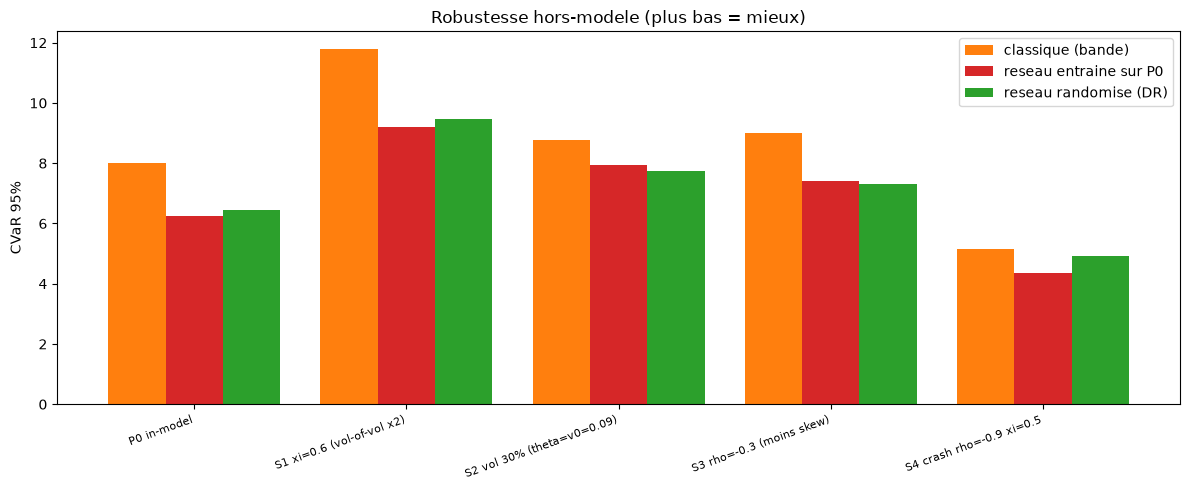

In [82]:
labels = list(scen.keys()); x = np.arange(len(labels)); wd = 0.27
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x-wd, [classic[k][1] for k in labels], wd, label='classique (bande)', color='tab:orange')
ax.bar(x,    [res_p0[k]    for k in labels], wd, label='reseau entraine sur P0', color='tab:red')
ax.bar(x+wd, [res_dr[k]    for k in labels], wd, label='reseau randomise (DR)', color='tab:green')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('CVaR 95%'); ax.set_title("Robustesse hors-modele (plus bas = mieux)")
ax.legend(); fig.tight_layout(); plt.show()


### 9.2 Blinding the network to volatility (notebook 14b)

So we removed the variance from the inputs. Even blind, the vanilla hedger stayed robust, because the quantity that drives its policy, roughly the probability of finishing in the money, barely moves across regimes, from 62 to 55 to 67 percent. Seeing the volatility was worth about 1 percent. In practice the true instantaneous variance is not observable anyway; a desk feeds the network an implied-volatility proxy, so this blind case is the extreme and reality sits between it and the variance-aware case.

In [83]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.stats import norm
from scipy.optimize import brentq

torch.manual_seed(0)
S0, K, mu, r, T = 100., 100., 0.05, 0.02, 1.0
n, cost, alpha = 63, 0.01, 0.95; dt = T/n

def cvar(p,a=0.95): l=-p; return l[l>=np.quantile(l,a)].mean()

P0 = (0.04, 2.0, 0.04, 0.3, -0.7)
scen = {'P0 in-model':                P0,
        'S1 xi=0.6':                  (0.04, 2.0, 0.04, 0.6, -0.7),
        'S2 vol 30%':                 (0.09, 2.0, 0.09, 0.3, -0.7),
        'S3 rho=-0.3':                (0.04, 2.0, 0.04, 0.3, -0.3),
        'S4 crash':                   (0.04, 2.0, 0.04, 0.5, -0.9)}
prem0 = heston_call(S0, P0[0], r, P0[1], P0[2], P0[3], P0[4], T, K)

def sim_np(par, m, seed):
    v0, kappa, theta, xi, rho = par; rng = np.random.default_rng(seed)
    S = np.empty((m, n+1)); v = np.empty((m, n+1)); S[:,0] = S0; v[:,0] = v0
    for k in range(n):
        Z1 = rng.standard_normal(m); Z2 = rho*Z1 + np.sqrt(1-rho**2)*rng.standard_normal(m)
        vk = np.maximum(v[:,k], 0.)
        v[:,k+1] = np.maximum(v[:,k] + kappa*(theta-vk)*dt + xi*np.sqrt(vk*dt)*Z2, 0.)
        S[:,k+1] = S[:,k]*np.exp((mu - 0.5*vk)*dt + np.sqrt(vk*dt)*Z1)
    return S, v
def band_hedge(S, premium, sig, band=0.13):
    m = S.shape[0]; times = np.linspace(0, T, n+1); cash = np.full(m, premium); pos = np.zeros(m)
    for k in range(n):
        tau = max(T-times[k], 1e-3); tgt = bs_delta(S[:,k], K, tau, r, sig)
        tr = np.where(np.abs(tgt-pos) > band, tgt-pos, 0.); cash -= tr*S[:,k] + cost*np.abs(tr)*S[:,k]; pos += tr; cash *= np.exp(r*dt)
    return cash + pos*S[:,-1] - np.maximum(S[:,-1]-K, 0.)

# reference classique (recalibree par scenario)
classic = {}
for name, par in scen.items():
    prem = heston_call(S0, par[0], r, par[1], par[2], par[3], par[4], T, K)
    sig = brentq(lambda s: bs_price(S0, K, T, r, s) - prem, 1e-3, 2.0)
    S, _ = sim_np(par, 60_000, 7)
    classic[name] = (prem, cvar(band_hedge(S, prem, sig)))
print("reference classique prete")


reference classique prete


In [84]:
def heston_paths_t(par, m):
    v0, kappa, theta, xi, rho = par
    S = torch.full((m,), S0); v = torch.full((m,), float(v0)); Ss = [S]
    for k in range(n):
        Z1 = torch.randn(m); Z2 = rho*Z1 + np.sqrt(1-rho**2)*torch.randn(m)
        vk = torch.clamp(v, min=0.)
        v = torch.clamp(v + kappa*(theta-vk)*dt + xi*torch.sqrt(vk*dt)*Z2, min=0.)
        S = S*torch.exp((mu - 0.5*vk)*dt + torch.sqrt(vk*dt)*Z1)
        Ss.append(S)
    return torch.stack(Ss, 1)                      # on ne renvoie que S : v n'est pas observe

def cvar_torch(L, a=0.95):
    var = torch.quantile(L, a); return L[L >= var].mean()

class BlindNet(torch.nn.Module):
    def __init__(self, h=32):
        super().__init__()
        self.net = torch.nn.Sequential(torch.nn.Linear(3, h), torch.nn.ReLU(),
                                       torch.nn.Linear(h, h), torch.nn.ReLU(), torch.nn.Linear(h, 1))
    def forward(self, x): return self.net(x).squeeze(-1)

def hedge_blind(net, S, premium):
    m = S.shape[0]; cash = torch.full((m,), premium); pos = torch.zeros(m)
    for k in range(n):
        tau = float(T - k*dt)
        feat = torch.stack([torch.log(S[:,k]/K), torch.full((m,), tau), pos], dim=1)   # PAS de v
        d = net(feat); tr = d - pos
        cash = cash - tr*S[:,k] - cost*torch.abs(tr)*S[:,k]; cash = cash*np.exp(r*dt); pos = d
    return cash + pos*S[:,-1] - torch.clamp(S[:,-1]-K, min=0.0)

def train_blind(sampler, epochs=400, m=20_000, lr=1e-3):
    net = BlindNet(); opt = torch.optim.Adam(net.parameters(), lr=lr)
    for ep in range(epochs):
        S = heston_paths_t(sampler(), m)
        loss = cvar_torch(-hedge_blind(net, S.detach(), prem0))
        opt.zero_grad(); loss.backward(); opt.step()
    return net

def eval_blind(net, par, prem, m=60_000, seed=7):
    Snp, _ = sim_np(par, m, seed)
    with torch.no_grad():
        pnl = hedge_blind(net, torch.tensor(Snp, dtype=torch.float32), prem).numpy()
    return cvar(pnl)

print("entrainement aveugle sur P0 ..."); blind_p0 = train_blind(lambda: P0)


entrainement aveugle sur P0 ...


In [85]:
rng_dr = np.random.default_rng(0)
def sampler_dr():
    theta = rng_dr.uniform(0.02, 0.09); xi = rng_dr.uniform(0.2, 0.6); rho = rng_dr.uniform(-0.9, -0.3)
    return (theta, 2.0, theta, xi, rho)
print("entrainement aveugle randomise ..."); blind_dr = train_blind(sampler_dr, epochs=600)

print(f"{'scenario':16s} {'classique':>10s} {'aveugle P0':>11s} {'aveugle DR':>11s}")
bP0, bDR = {}, {}
for name, par in scen.items():
    prem = classic[name][0]
    bP0[name] = eval_blind(blind_p0, par, prem); bDR[name] = eval_blind(blind_dr, par, prem)
    print(f"{name:16s} {classic[name][1]:10.2f} {bP0[name]:11.2f} {bDR[name]:11.2f}")


entrainement aveugle randomise ...
scenario          classique  aveugle P0  aveugle DR
P0 in-model            8.00        6.19        6.74
S1 xi=0.6             11.79        9.05        9.57
S2 vol 30%             8.78        8.05        7.96
S3 rho=-0.3            8.99        7.30        7.36
S4 crash               5.15        4.23        5.27


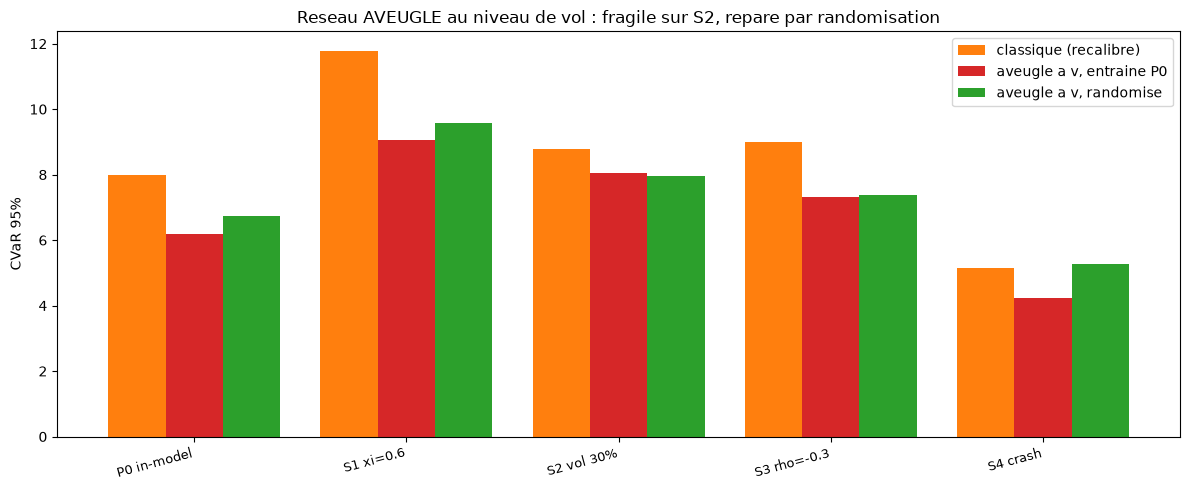

In [86]:
labels = list(scen.keys()); x = np.arange(len(labels)); wd = 0.27
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x-wd, [classic[k][1] for k in labels], wd, label='classique (recalibre)', color='tab:orange')
ax.bar(x,    [bP0[k]        for k in labels], wd, label='aveugle a v, entraine P0', color='tab:red')
ax.bar(x+wd, [bDR[k]        for k in labels], wd, label='aveugle a v, randomise', color='tab:green')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('CVaR 95%'); ax.set_title("Reseau AVEUGLE au niveau de vol : fragile sur S2, repare par randomisation")
ax.legend(); fig.tight_layout(); plt.show()


### 9.3 The product that finally broke (notebook 14c)

The barrier is the opposite of the vanilla. This time we measured the driver before predicting: the knockout probability roughly triples across regimes. A barrier hedger blind to volatility is fine at the base parameters and breaks in the high-volatility regime, where seeing the volatility is worth about 18 percent of CVaR, against 1 percent for the vanilla, and domain randomization repairs most of the gap.

The conclusion is sharper than the folklore. Robustness is a property of the product and of what the network can observe, not of deep hedging as a method. You worry about overfitting the simulator exactly on products whose optimal policy depends on a regime variable the network cannot see, and you fix it by giving it the information or by randomizing the training.

In [87]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import norm

torch.manual_seed(0)
S0, K, mu, r, T = 100., 100., 0.05, 0.02, 1.0
n, cost, alpha = 63, 0.01, 0.95; dt = T/n; Bar = 130.0

from scipy.optimize import brentq
def cvar(p,a=0.95): l=-p; return l[l>=np.quantile(l,a)].mean()

def sim_np(par, m, seed, drift):
    v0,kappa,theta,xi,rho=par; rng=np.random.default_rng(seed)
    S=np.empty((m,n+1)); v=np.empty((m,n+1)); S[:,0]=S0; v[:,0]=v0
    for k in range(n):
        Z1=rng.standard_normal(m); Z2=rho*Z1+np.sqrt(1-rho**2)*rng.standard_normal(m)
        vk=np.maximum(v[:,k],0.)
        v[:,k+1]=np.maximum(v[:,k]+kappa*(theta-vk)*dt+xi*np.sqrt(vk*dt)*Z2,0.)
        S[:,k+1]=S[:,k]*np.exp((drift-0.5*vk)*dt+np.sqrt(vk*dt)*Z1)
    return S,v

P0=(0.04,2.0,0.04,0.3,-0.7)
scen={'P0':P0,'S1 xi=0.6':(0.04,2,0.04,0.6,-0.7),'S2 vol30%':(0.09,2,0.09,0.3,-0.7),
      'S3 rho=-0.3':(0.04,2,0.04,0.3,-0.3),'S4 crash':(0.04,2,0.04,0.5,-0.9)}
times=np.linspace(0,T,n+1)

# prime de barriere (MC risque-neutre) + reference delta BS-barriere, par scenario
ref={}
for name,par in scen.items():
    Sq,_=sim_np(par,120000,1,r); kn=(Sq.max(axis=1)>=Bar)
    prem=float(np.exp(-r*T)*np.where(~kn,np.maximum(Sq[:,-1]-K,0.),0.).mean())
    pv=bs_price  # placeholder
    # vol implicite ATM recalibree (prix vanille Heston approxime par MC risque-neutre)
    premvan=float(np.exp(-r*T)*np.maximum(Sq[:,-1]-K,0.).mean())
    sig=brentq(lambda s: bs_price(S0,K,T,r,s)-premvan,1e-3,2.0)
    S,v=sim_np(par,60000,7,mu); alive=np.cumprod((S<Bar).astype(float),axis=1)
    payoff=np.where(alive[:,-1]>0,np.maximum(S[:,-1]-K,0.),0.)
    cash=np.full(60000,prem); pos=np.zeros(60000)
    for k in range(n):
        tau=max(T-times[k],1e-3); tgt=bs_uo_delta(S[:,k],K,Bar,tau,r,sig)*alive[:,k]
        tr=tgt-pos; cash-=tr*S[:,k]+cost*np.abs(tr)*S[:,k]; pos=tgt; cash*=np.exp(r*dt)
    ref[name]=dict(prem=prem, knock=kn.mean(), delta=cvar(cash+pos*S[:,-1]-payoff))
    print(f"{name:12s} knock={kn.mean():5.1%}  prime={prem:5.2f}  classique(deltaBS)={ref[name]['delta']:6.2f}")
prem_P0=ref['P0']['prem']


P0           knock=10.4%  prime= 5.48  classique(deltaBS)= 26.54
S1 xi=0.6    knock= 5.8%  prime= 6.59  classique(deltaBS)= 29.40
S2 vol30%    knock=29.8%  prime= 2.65  classique(deltaBS)= 17.98
S3 rho=-0.3  knock=13.8%  prime= 4.32  classique(deltaBS)= 23.49
S4 crash     knock= 2.3%  prime= 7.70  classique(deltaBS)= 31.54


In [88]:
def paths_t(par, m):
    v0,kappa,theta,xi,rho=par
    S=torch.full((m,),S0); v=torch.full((m,),float(v0)); Ss=[S]; vs=[v]
    for k in range(n):
        Z1=torch.randn(m); Z2=rho*Z1+np.sqrt(1-rho**2)*torch.randn(m)
        vk=torch.clamp(v,min=0.)
        v=torch.clamp(v+kappa*(theta-vk)*dt+xi*torch.sqrt(vk*dt)*Z2,min=0.)
        S=S*torch.exp((mu-0.5*vk)*dt+torch.sqrt(vk*dt)*Z1); Ss.append(S); vs.append(v)
    return torch.stack(Ss,1), torch.stack(vs,1)

def cvar_torch(L,a=0.95): var=torch.quantile(L,a); return L[L>=var].mean()

class Net(torch.nn.Module):
    def __init__(self, d, h=48):
        super().__init__()
        self.net=torch.nn.Sequential(torch.nn.Linear(d,h),torch.nn.ReLU(),
                                     torch.nn.Linear(h,h),torch.nn.ReLU(),torch.nn.Linear(h,1))
    def forward(self,x): return self.net(x).squeeze(-1)

def barrier_pnl(net, S, v, premium, use_v):
    m=S.shape[0]; cash=torch.full((m,),premium); pos=torch.zeros(m); alive=torch.ones(m)
    for k in range(n):
        alive=alive*(S[:,k]<Bar).float()               # 0 une fois la barriere franchie
        tau=float(T-k*dt); dist=(Bar-S[:,k])/S0
        if use_v:
            feat=torch.stack([torch.log(S[:,k]/K),torch.full((m,),tau),pos,v[:,k],dist,alive],1)
        else:
            feat=torch.stack([torch.log(S[:,k]/K),torch.full((m,),tau),pos,dist,alive],1)
        d=net(feat); tr=d-pos
        cash=cash-tr*S[:,k]-cost*torch.abs(tr)*S[:,k]; cash=cash*np.exp(r*dt); pos=d
    alive=alive*(S[:,-1]<Bar).float()
    payoff=torch.clamp(S[:,-1]-K,min=0.)*alive
    return cash+pos*S[:,-1]-payoff

def train(use_v, sampler, epochs=500, m=20000, lr=1e-3):
    net=Net(6 if use_v else 5); opt=torch.optim.Adam(net.parameters(),lr=lr)
    for ep in range(epochs):
        S,v=paths_t(sampler(),m)
        loss=cvar_torch(-barrier_pnl(net,S.detach(),v.detach(),prem_P0,use_v))
        opt.zero_grad(); loss.backward(); opt.step()
        if (ep+1)%100==0: print(f"  ep {ep+1}  CVaR train = {loss.item():.3f}")
    return net

def eval_net(net, use_v, par, prem, m=60000, seed=7):
    Snp,vnp=sim_np(par,m,seed,mu)
    with torch.no_grad():
        pnl=barrier_pnl(net,torch.tensor(Snp,dtype=torch.float32),
                        torch.tensor(vnp,dtype=torch.float32),prem,use_v).numpy()
    return cvar(pnl)

print("1) reseau qui VOIT v, entraine sur P0"); net_v = train(True, lambda: P0)
print("2) reseau AVEUGLE a v, entraine sur P0"); net_blind = train(False, lambda: P0)


1) reseau qui VOIT v, entraine sur P0
  ep 100  CVaR train = 9.608
  ep 200  CVaR train = 8.235
  ep 300  CVaR train = 7.944
  ep 400  CVaR train = 7.717
  ep 500  CVaR train = 7.506
2) reseau AVEUGLE a v, entraine sur P0
  ep 100  CVaR train = 8.571
  ep 200  CVaR train = 8.062
  ep 300  CVaR train = 7.974
  ep 400  CVaR train = 7.944
  ep 500  CVaR train = 7.725


In [89]:
rng_dr=np.random.default_rng(0)
def sampler_dr():
    theta=rng_dr.uniform(0.02,0.09); xi=rng_dr.uniform(0.2,0.6); rho=rng_dr.uniform(-0.9,-0.3)
    return (theta,2.0,theta,xi,rho)
print("3) reseau AVEUGLE randomise (DR)"); net_blind_dr = train(False, sampler_dr, epochs=700)

print(f"{'scenario':12s} {'classique':>10s} {'voit v':>8s} {'aveugle':>8s} {'aveugle+DR':>11s}")
V,B,BDR={},{},{}
for name,par in scen.items():
    prem=ref[name]['prem']
    V[name]=eval_net(net_v,True,par,prem); B[name]=eval_net(net_blind,False,par,prem); BDR[name]=eval_net(net_blind_dr,False,par,prem)
    print(f"{name:12s} {ref[name]['delta']:10.2f} {V[name]:8.2f} {B[name]:8.2f} {BDR[name]:11.2f}")


3) reseau AVEUGLE randomise (DR)
  ep 100  CVaR train = 11.215
  ep 200  CVaR train = 9.744
  ep 300  CVaR train = 9.672
  ep 400  CVaR train = 9.757
  ep 500  CVaR train = 10.657
  ep 600  CVaR train = 8.268
  ep 700  CVaR train = 9.581
scenario      classique   voit v  aveugle  aveugle+DR
P0                26.54     7.50     7.77        8.64
S1 xi=0.6         29.40     8.12     8.59        8.66
S2 vol30%         17.98    12.06    14.22       12.51
S3 rho=-0.3       23.49     8.49     9.09        9.39
S4 crash          31.54     6.13     6.36        7.24


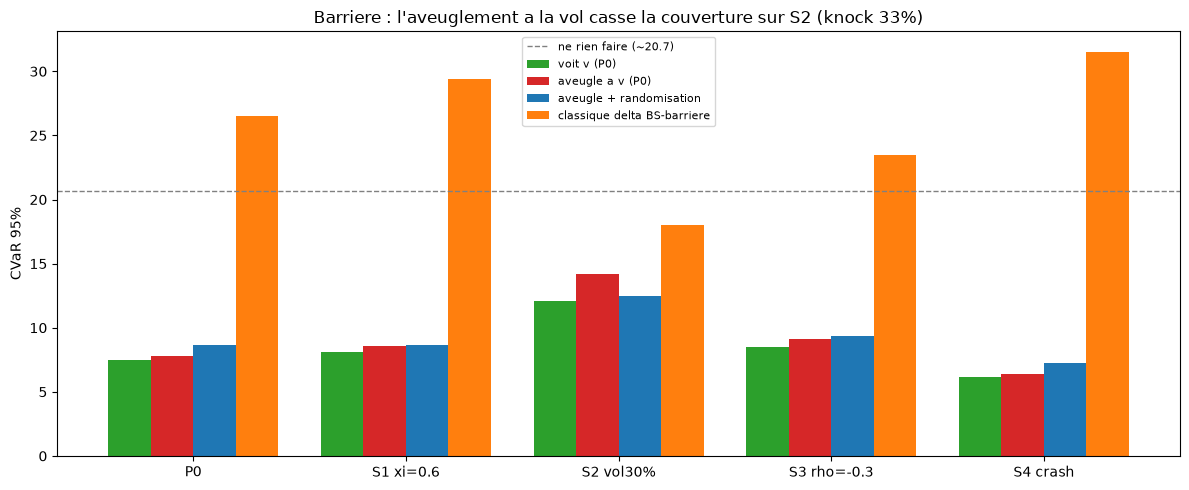

In [90]:
labels=list(scen.keys()); x=np.arange(len(labels)); wd=0.2
fig,ax=plt.subplots(figsize=(12,5))
ax.bar(x-1.5*wd,[V[k] for k in labels],wd,label='voit v (P0)',color='tab:green')
ax.bar(x-0.5*wd,[B[k] for k in labels],wd,label='aveugle a v (P0)',color='tab:red')
ax.bar(x+0.5*wd,[BDR[k] for k in labels],wd,label='aveugle + randomisation',color='tab:blue')
ax.bar(x+1.5*wd,[ref[k]['delta'] for k in labels],wd,label='classique delta BS-barriere',color='tab:orange')
ax.axhline(20.7,color='gray',ls='--',lw=1,label='ne rien faire (~20.7)')
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('CVaR 95%')
ax.set_title("Barriere : l'aveuglement a la vol casse la couverture sur S2 (knock 33%)")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()


## Chapter 10. The hedger is a pricer

### 10.1 Indifference price and the bid-ask spread (notebook 15)

Because CVaR is translation invariant, the smallest premium that makes a hedged short position acceptable is `exp(-rT)` times the minimal residual CVaR, which is exactly what the network minimizes. The same object that hedges also prices. The ask is the discounted residual risk of the short position, the bid is minus that of the long, and the spread is `exp(-rT)` times the sum of the two residual risks. With no frictions and a complete market both residuals vanish and bid and ask collapse onto the risk-neutral price, so the spread is entirely the price of frictions and unhedgeable risk.

Priced this way on three products, the relative spread is tightest on the vanilla, wider on a digital whose delta explodes at the strike, widest on the barrier. The network tightens the barrier spread by about 65 percent against the classical hedge, the largest tightening of the three, exactly where the classical hedge fails.

In [91]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import norm

torch.manual_seed(0)
S0, K, r, T, sigma = 100., 100., 0.02, 1.0, 0.20
n, cost, alpha = 63, 0.01, 0.95; dt = T/n; Bar = 130.0

# --- prix risque-neutre fermes (references) ---
def d12(S, tau): d1=(np.log(S/K)+(r+0.5*sigma**2)*tau)/(sigma*np.sqrt(tau)); return d1, d1-sigma*np.sqrt(tau)
def bs_call(S, tau): d1,d2=d12(S,tau); return S*norm.cdf(d1)-K*np.exp(-r*tau)*norm.cdf(d2)
def bs_call_delta(S, tau): d1,_=d12(S,tau); return norm.cdf(d1)
def dig_price(S, tau): _,d2=d12(S,tau); return np.exp(-r*tau)*norm.cdf(d2)
def dig_delta(S, tau): _,d2=d12(S,tau); return np.exp(-r*tau)*norm.pdf(d2)/(S*sigma*np.sqrt(tau))
def uo_call(S, tau, sig=sigma):
    S=np.asarray(S,float); H=Bar; srt=sig*np.sqrt(tau); m_=(r-0.5*sig**2)/sig**2
    x1=np.log(S/K)/srt+(1+m_)*srt; x2=np.log(S/H)/srt+(1+m_)*srt
    y1=np.log(H**2/(S*K))/srt+(1+m_)*srt; y2=np.log(H/S)/srt+(1+m_)*srt
    A=S*norm.cdf(x1)-K*np.exp(-r*tau)*norm.cdf(x1-srt); B=S*norm.cdf(x2)-K*np.exp(-r*tau)*norm.cdf(x2-srt)
    C=S*(H/S)**(2*(m_+1))*norm.cdf(-y1)-K*np.exp(-r*tau)*(H/S)**(2*m_)*norm.cdf(-y1+srt)
    D=S*(H/S)**(2*(m_+1))*norm.cdf(-y2)-K*np.exp(-r*tau)*(H/S)**(2*m_)*norm.cdf(-y2+srt)
    return np.where(S>=H,0.,A-B+C-D)
def uo_delta(S, tau, h=0.5): return (uo_call(S+h,tau)-uo_call(S-h,tau))/(2*h)
def CVaR(loss, a=0.95): return loss[loss>=np.quantile(loss,a)].mean()

RN = {'call': float(bs_call(S0,T)), 'barriere': float(uo_call(S0,T)), 'digitale': float(dig_price(S0,T))}
print("prix risque-neutre :", {k: round(v,3) for k,v in RN.items()})


prix risque-neutre : {'call': 8.916, 'barriere': 3.129, 'digitale': 0.49}


In [92]:
rng = np.random.default_rng(0); times = np.linspace(0,T,n+1)
def sim_np(m):
    Z=rng.standard_normal((m,n)); inc=(r-0.5*sigma**2)*dt+sigma*np.sqrt(dt)*Z
    return S0*np.exp(np.concatenate([np.zeros((m,1)),np.cumsum(inc,axis=1)],axis=1))
Sc = sim_np(200_000); alive_c = np.cumprod((Sc<Bar).astype(float),axis=1)
prod = {
 'call':     dict(payoff=np.maximum(Sc[:,-1]-K,0.),                      delta=lambda s,t: bs_call_delta(s,t), gate=None),
 'barriere': dict(payoff=np.where(alive_c[:,-1]>0,np.maximum(Sc[:,-1]-K,0.),0.), delta=lambda s,t: uo_delta(s,t), gate=alive_c),
 'digitale': dict(payoff=(Sc[:,-1]>=K).astype(float),                    delta=lambda s,t: dig_delta(s,t),     gate=None),
}
def classic_gains(delta, sign, gate):
    m=Sc.shape[0]; cash=np.zeros(m); pos=np.zeros(m)
    for k in range(n):
        tau=max(T-times[k],1e-3); g=1.0 if gate is None else gate[:,k]
        tgt=sign*delta(Sc[:,k],tau)*g; tr=tgt-pos; cash-=tr*Sc[:,k]+cost*np.abs(tr)*Sc[:,k]; pos+=tr; cash*=np.exp(r*dt)
    return cash+pos*Sc[:,-1]
classic = {}
for name,p in prod.items():
    a=CVaR(p['payoff']-classic_gains(p['delta'],+1,p['gate']))
    b=CVaR(-classic_gains(p['delta'],-1,p['gate'])-p['payoff'])
    classic[name]=(np.exp(-r*T)*a, -np.exp(-r*T)*b)
    print(f"{name:10s} RN={RN[name]:6.3f}  ask={classic[name][0]:6.2f}  bid={classic[name][1]:6.2f}  spread={classic[name][0]-classic[name][1]:6.2f}")


call       RN= 8.916  ask= 15.25  bid=  3.29  spread= 11.96
barriere   RN= 3.129  ask= 20.60  bid= -9.93  spread= 30.53
digitale   RN= 0.490  ask=  1.10  bid= -0.12  spread=  1.22


In [93]:
def sim_gbm_t(m):
    Z=torch.randn(m,n); inc=(r-0.5*sigma**2)*dt+sigma*np.sqrt(dt)*Z
    logS=torch.cat([torch.zeros(m,1), torch.cumsum(inc,dim=1)],dim=1)
    return S0*torch.exp(logS)
def cvar_torch(L,a=0.95): var=torch.quantile(L,a); return L[L>=var].mean()

class Net(torch.nn.Module):
    def __init__(self,d,h=32):
        super().__init__()
        self.net=torch.nn.Sequential(torch.nn.Linear(d,h),torch.nn.ReLU(),
                                     torch.nn.Linear(h,h),torch.nn.ReLU(),torch.nn.Linear(h,1))
    def forward(self,x): return self.net(x).squeeze(-1)

def gains_t(net, S, barrier):
    m=S.shape[0]; cash=torch.zeros(m); pos=torch.zeros(m); alive=torch.ones(m)
    for k in range(n):
        tau=float(T-k*dt)
        if barrier:
            alive=alive*(S[:,k]<Bar).float()
            feat=torch.stack([torch.log(S[:,k]/K),torch.full((m,),tau),pos,(Bar-S[:,k])/S0,alive],1)
        else:
            feat=torch.stack([torch.log(S[:,k]/K),torch.full((m,),tau),pos],1)
        d=net(feat); tr=d-pos; cash=cash-tr*S[:,k]-cost*torch.abs(tr)*S[:,k]; cash=cash*np.exp(r*dt); pos=d
    return cash+pos*S[:,-1]

def payoff_t(S, kind):
    if kind=='call':     return torch.clamp(S[:,-1]-K,min=0.)
    if kind=='digitale': return (S[:,-1]>=K).float()
    if kind=='barriere':
        alive=torch.prod((S<Bar).float(),dim=1); return torch.clamp(S[:,-1]-K,min=0.)*alive

def train_side(kind, side, epochs=300, m=20000, lr=1e-3):
    barrier=(kind=='barriere'); net=Net(5 if barrier else 3); opt=torch.optim.Adam(net.parameters(),lr)
    for ep in range(epochs):
        S=sim_gbm_t(m).detach(); g=gains_t(net,S,barrier); pay=payoff_t(S,kind)
        L = (pay-g) if side=='ask' else (-g-pay)
        loss=cvar_torch(L); opt.zero_grad(); loss.backward(); opt.step()
    return net

def price_side(net, kind, side, m=100000):
    barrier=(kind=='barriere')
    with torch.no_grad():
        S=sim_gbm_t(m); g=gains_t(net,S,barrier); pay=payoff_t(S,kind)
        L=(pay-g) if side=='ask' else (-g-pay)
        return float(np.exp(-r*T)*CVaR(L.numpy())) * (1 if side=='ask' else -1)

net_price={}
for kind in ['call','barriere','digitale']:
    print(f"entrainement {kind} ...")
    na=train_side(kind,'ask'); nb=train_side(kind,'bid')
    net_price[kind]=(price_side(na,kind,'ask'), price_side(nb,kind,'bid'))
    print(f"   ask={net_price[kind][0]:.3f}  bid={net_price[kind][1]:.3f}")


entrainement call ...
   ask=13.516  bid=4.793
entrainement barriere ...
   ask=10.754  bid=-0.027
entrainement digitale ...
   ask=0.906  bid=0.119


produit     prixRN | spread classique | spread reseau
call         8.916 |            11.96 |          8.72
barriere     3.129 |            30.53 |         10.78
digitale     0.490 |             1.22 |          0.79


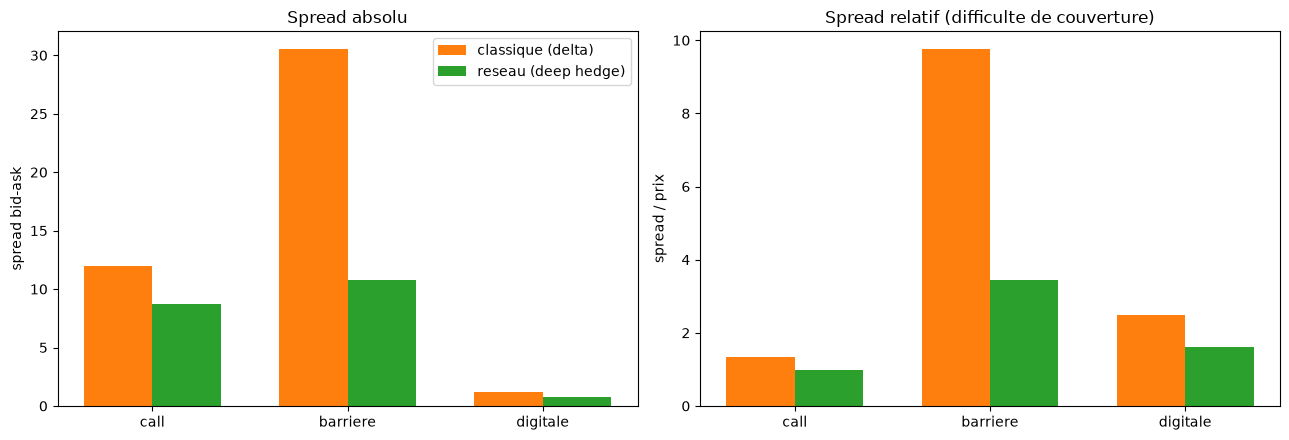

In [94]:
print(f"{'produit':10s} {'prixRN':>7s} | {'spread classique':>16s} | {'spread reseau':>13s}")
for kind in ['call','barriere','digitale']:
    sc=classic[kind][0]-classic[kind][1]; sn=net_price[kind][0]-net_price[kind][1]
    print(f"{kind:10s} {RN[kind]:7.3f} | {sc:16.2f} | {sn:13.2f}")

kinds=['call','barriere','digitale']; x=np.arange(3); wd=0.35
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,4.5))
ax1.bar(x-wd/2,[(classic[k][0]-classic[k][1]) for k in kinds],wd,label='classique (delta)',color='tab:orange')
ax1.bar(x+wd/2,[(net_price[k][0]-net_price[k][1]) for k in kinds],wd,label='reseau (deep hedge)',color='tab:green')
ax1.set_xticks(x); ax1.set_xticklabels(kinds); ax1.set_ylabel('spread bid-ask'); ax1.set_title('Spread absolu'); ax1.legend()
ax2.bar(x-wd/2,[(classic[k][0]-classic[k][1])/RN[k] for k in kinds],wd,color='tab:orange')
ax2.bar(x+wd/2,[(net_price[k][0]-net_price[k][1])/RN[k] for k in kinds],wd,color='tab:green')
ax2.set_xticks(x); ax2.set_xticklabels(kinds); ax2.set_ylabel('spread / prix'); ax2.set_title('Spread relatif (difficulte de couverture)')
fig.tight_layout(); plt.show()


### 10.2 Making the spread realistic (notebook 15b)

The raw spreads under a 95 percent single-trade CVaR and a 1 percent cost are far too wide to be real quotes, and we did not hide that. Calibrating like a desk, a few basis points of cost, frequent rebalancing, and a risk loading that is a small fraction of the full CVaR because a desk warehouses risk across a book, the vanilla spread lands around 3 to 11 percent of the premium, the right order of magnitude for a liquid option. We model the risk appetite with the coherent measure rho_lambda = (1 - lambda) E + lambda CVaR, where small lambda is a diversified desk. The exotic spreads stay wide even at low cost, because the barrier's gap risk is intrinsic rather than cost driven, which is the concrete reason a desk needs a better hedger to quote exotics competitively.

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

S0,K,r,T,sigma = 100.,100.,0.02,1.0,0.20; Bar=130.
def d12(S,tau): d1=(np.log(S/K)+(r+0.5*sigma**2)*tau)/(sigma*np.sqrt(tau)); return d1,d1-sigma*np.sqrt(tau)
def bs_call(S,tau): d1,d2=d12(S,tau); return S*norm.cdf(d1)-K*np.exp(-r*tau)*norm.cdf(d2)
def bs_delta(S,tau): d1,_=d12(S,tau); return norm.cdf(d1)
def CVaR(L,a): return L[L>=np.quantile(L,a)].mean()
def rho(L,a,lam): return (1-lam)*L.mean()+lam*CVaR(L,a)
pBS=float(bs_call(S0,T)); alpha=0.95
print(f"prix BS du call = {pBS:.3f}")


prix BS du call = 8.916


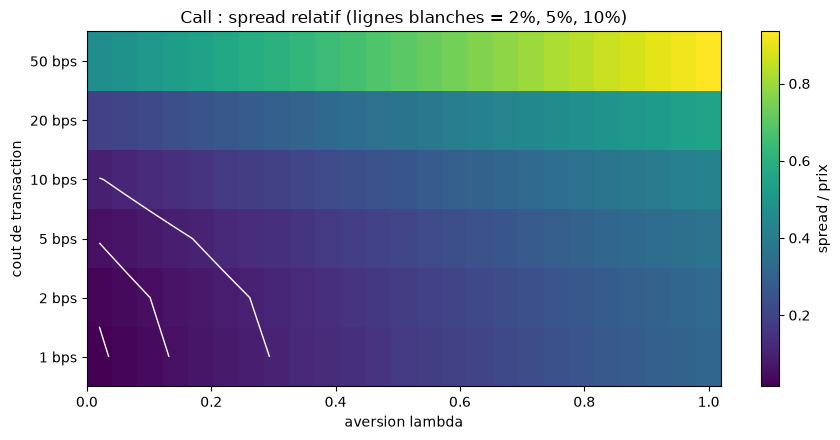

cout 5 bps, lambda=0.2: spread=0.978 soit 11.0% du prix
cout 2 bps, lambda=0.1: spread=0.441 soit 4.9% du prix
cout 2 bps, lambda=0.05: spread=0.302 soit 3.4% du prix


In [96]:
n=126; dt=T/n; times=np.linspace(0,T,n+1); rng=np.random.default_rng(0); m=60000
Z=rng.standard_normal((m,n)); S=S0*np.exp(np.concatenate([np.zeros((m,1)),np.cumsum((r-0.5*sigma**2)*dt+sigma*np.sqrt(dt)*Z,axis=1)],axis=1))
payoff=np.maximum(S[:,-1]-K,0.)
def gains(sign,cost):
    cash=np.zeros(m); pos=np.zeros(m)
    for k in range(n):
        tau=max(T-times[k],1e-4); tgt=sign*bs_delta(S[:,k],tau); tr=tgt-pos
        cash-=tr*S[:,k]+cost*np.abs(tr)*S[:,k]; pos+=tr; cash*=np.exp(r*dt)
    return cash+pos*S[:,-1]
costs=np.array([1,2,5,10,20,50])*1e-4          # de 1 a 50 bps
lams=np.linspace(0.02,1.0,25)
disc=np.exp(-r*T)
grid=np.zeros((len(costs),len(lams)))
for i,c in enumerate(costs):
    La=payoff-gains(+1,c); Lb=-gains(-1,c)-payoff
    for j,lam in enumerate(lams):
        grid[i,j]=disc*(rho(La,alpha,lam)+rho(Lb,alpha,lam))/pBS   # spread relatif
fig,ax=plt.subplots(figsize=(9,4.5))
im=ax.pcolormesh(lams,np.arange(len(costs)),grid,shading='auto',cmap='viridis')
ax.set_yticks(np.arange(len(costs))); ax.set_yticklabels([f"{int(c*1e4)} bps" for c in costs])
fig.colorbar(im,label='spread / prix'); ax.set_xlabel('aversion lambda'); ax.set_ylabel('cout de transaction')
ax.contour(lams,np.arange(len(costs)),grid,levels=[0.02,0.05,0.10],colors='white',linewidths=1)
ax.set_title('Call : spread relatif (lignes blanches = 2%, 5%, 10%)')
fig.tight_layout(); plt.show()
# quelques points de fonctionnement
for c,lam in [(0.0005,0.2),(0.0002,0.1),(0.0002,0.05)]:
    La=payoff-gains(+1,c); Lb=-gains(-1,c)-payoff
    s=disc*(rho(La,alpha,lam)+rho(Lb,alpha,lam))
    print(f"cout {int(c*1e4)} bps, lambda={lam}: spread={s:.3f} soit {s/pBS:.1%} du prix")


In [97]:
def uo(S,tau):
    S=np.asarray(S,float); H=Bar; srt=sigma*np.sqrt(tau); m_=(r-0.5*sigma**2)/sigma**2
    x1=np.log(S/K)/srt+(1+m_)*srt; x2=np.log(S/H)/srt+(1+m_)*srt
    y1=np.log(H**2/(S*K))/srt+(1+m_)*srt; y2=np.log(H/S)/srt+(1+m_)*srt
    A=S*norm.cdf(x1)-K*np.exp(-r*tau)*norm.cdf(x1-srt); B=S*norm.cdf(x2)-K*np.exp(-r*tau)*norm.cdf(x2-srt)
    C=S*(H/S)**(2*(m_+1))*norm.cdf(-y1)-K*np.exp(-r*tau)*(H/S)**(2*m_)*norm.cdf(-y1+srt)
    D=S*(H/S)**(2*(m_+1))*norm.cdf(-y2)-K*np.exp(-r*tau)*(H/S)**(2*m_)*norm.cdf(-y2+srt)
    return np.where(S>=H,0.,A-B+C-D)
def uo_delta(S,tau,h=0.5): return (uo(S+h,tau)-uo(S-h,tau))/(2*h)
alive=np.cumprod((S<Bar).astype(float),axis=1)
pay_bar=np.where(alive[:,-1]>0,np.maximum(S[:,-1]-K,0.),0.); RN_bar=float(uo(S0,T))
c,lam=0.0005,0.2
def gains_bar(sign):
    cash=np.zeros(m); pos=np.zeros(m)
    for k in range(n):
        tau=max(T-times[k],1e-4); tgt=sign*uo_delta(S[:,k],tau)*alive[:,k]; tr=tgt-pos
        cash-=tr*S[:,k]+c*np.abs(tr)*S[:,k]; pos+=tr; cash*=np.exp(r*dt)
    return cash+pos*S[:,-1]
sb=disc*(rho(pay_bar-gains_bar(1),alpha,lam)+rho(-gains_bar(-1)-pay_bar,alpha,lam))
print(f"barriere, classique, point realiste (5bps, lambda=0.2): spread = {sb:.3f} soit {sb/RN_bar:.0%} du prix")
print("=> le delta classique ne suffit pas : c'est le deep hedger (notebook 13) qui resserre ce spread,")
print("   car il apprend a couper la couverture pres du seuil, ce que le delta ne fait pas.")


barriere, classique, point realiste (5bps, lambda=0.2): spread = 2.338 soit 75% du prix
=> le delta classique ne suffit pas : c'est le deep hedger (notebook 13) qui resserre ce spread,
   car il apprend a couper la couverture pres du seuil, ce que le delta ne fait pas.


## The difficulties log

Collected in one place, the obstacles that actually cost us time and what we did about each. These are the parts worth being able to talk through.

**Understanding Heston before coding it.** Why the simulation is sequential rather than a cumulative sum (the increment depends on the current variance), and that `theta` is a variance so the volatility is its square root. Resolved by deriving the reduction to GBM when the vol-of-vol is zero and testing it to machine precision.

**No GPU in the prototyping sandbox.** Every numerical result was checked in numpy first, and the PyTorch training was run separately. Slower, but it is why the numbers held up and why the honest post-mortems below exist.

**The good number that was partly a mirage (chapter 7).** The multi-instrument CVaR of 2.45 came mostly from adding an option that carries vega, captured even by a static hedge at 3.90, not from clever dynamics. We only found this by inspecting what the network actually held and by testing the static hedge. The classical delta-vega benchmark at 6.54 was itself beaten by holding one option, because it over-trades under cost.

**The barrier that would not train (chapter 8).** Three runs worse than the static hedge (10.36, 10.69, 11.52). We eliminated a bad starting point with residual hedging and a zero-initialized last layer, eliminated overfitting with fresh Monte Carlo every epoch, and finally found the real cause: the Rockafellar-Uryasev auxiliary variable is stuck near zero under Adam, so the loss was the mean instead of the tail. The direct empirical CVaR fixed it and the network reached 4.96.

**Two robustness hypotheses, both wrong (chapter 9).** We predicted the network would be fragile out of model, and it was not, twice. The correction was conceptual: robustness depends on whether the network observes the variable that drives the optimal policy. That reframing, forced by the null results, is the strongest single idea in the project.

**Spreads too wide to be real (chapter 10).** The single-trade 95 percent CVaR with a 1 percent cost gives absurd quotes. We separated the two levers, realistic cost in basis points and a risk-appetite parameter lambda that reflects book diversification, and recovered spreads in the few-percent range for a liquid vanilla.


## Epilogue. What we built, and what to distrust

The arc is complete, from a simulator to a quote: geometric Brownian motion, transaction costs, incompleteness under Heston, a second instrument, an exotic barrier, robustness to model misspecification, and pricing. The honest reckonings mattered as much as the wins.

What to distrust, stated plainly. The absolute CVaR levels are aggressive on purpose: a 95 percent tail measure, paths under the real-world drift while options are priced risk-neutrally so a small risk premium leaks in, and every product priced as a single trade with no book diversification. The relative comparisons, network against classical and product against product, are the trustworthy part, and those are the only things reported as conclusions. The Heston parameters are fixed rather than calibrated to a real surface, and nothing here models jumps, which would add a genuinely unhedgeable risk.

The three things worth saying out loud. Deep hedging matches the classics when the problem is easy and beats them when it is hard, so the interesting claim is always about the hard case. Robustness is a property of the product and of what the network observes, not of the method. And hedging and pricing are one problem: the residual risk of the best hedge is the price of the option and the width of its spread.
